In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from scipy.optimize import minimize
from scipy.stats import norm 
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import random
from random import sample



In [3]:
train_data=np.loadtxt("ECG200_TRAIN.txt")
test_data=np.loadtxt("ECG200_TEST.txt")

In [4]:
import pickle

with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = data['x']
y = data['y']

ai_data = [y == 0]
human_data = x[y == 1]

In [8]:
import pandas as pd

# Load the uploaded pickle file
data_path = "data_v2.pkl"
df_loaded = pd.read_pickle(data_path)

try:
    df_loaded = pd.read_pickle("data_v2.pkl")
    df_loaded.head()
except Exception as e:
    error_message = str(e)
    error_message

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDri


Bayesian Optimisation Results (sampled center-width pairs with error rates):
    Center  Width  Error Rate
0       86     10        0.10
1        5     24        0.20
2       18      4        0.15
3       75     20        0.10
4       89      9        0.20
5       28      7        0.10
6       63     17        0.25
7       13     11        0.25
8       80     21        0.10
9       29     23        0.10
10      76      4        0.25
11      40     30        0.10
12      82     14        0.10
13      73     30        0.20
14      22     30        0.10
15      38      4        0.15
16      31     30        0.15
17      38     18        0.10
18       0     30        0.20
19      95     30        0.05
20      89     30        0.05
21       0      4        0.20
22      91     25        0.05
23      92     29        0.05
24      50     30        0.10
25      88     26        0.05
26      14     30        0.10
27      45     24        0.20
28      31     15        0.20
29      28      4     

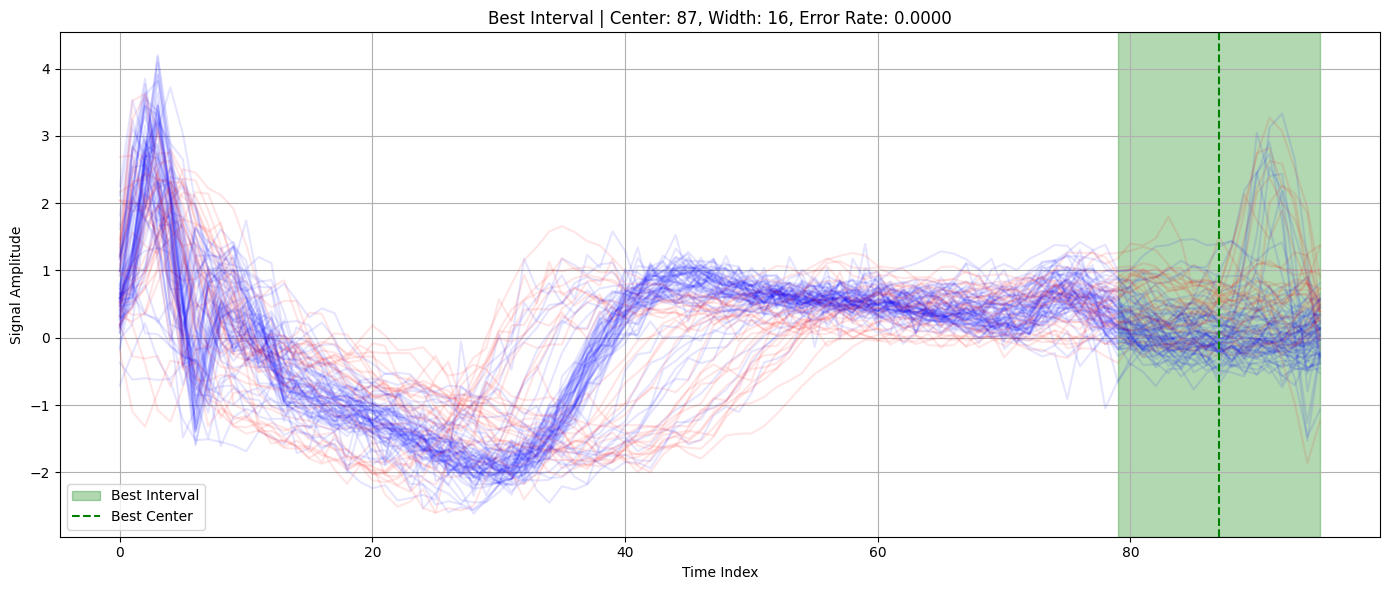

In [74]:
#parametrised width interval, ECG data, MLP
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import pandas as pd

# Load ECG data
train_data=np.loadtxt("ECG200_TRAIN.txt")
test_data=np.loadtxt("ECG200_TEST.txt")

# Extract labels and features
labels = train_data[:, 0]
features = train_data[:, 1:]

# Define bounds
center_bounds = (0, features.shape[1] - 1)
width_bounds = (4, min(30, features.shape[1]))

# Define interval extraction
def get_sampled_interval(data, center, width):
    start = max(0, int(center - width // 2))
    end = min(data.shape[1], int(center + width // 2))
    return start, end

# Neural network training and error evaluation
def train_nn(data, labels, center, width):
    start, end = get_sampled_interval(data, center, width)
    x = data[:, start:end]
    x_train, x_test, y_train, y_test = train_test_split(x, labels, test_size=0.2, random_state=42, stratify=labels)
    nn_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
    nn_model.fit(x_train, y_train)
    y_pred = nn_model.predict(x_test)
    return 1 - accuracy_score(y_test, y_pred)

# Expected improvement acquisition function
def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Initial sampling
n_initial = 10
initial_centers = np.random.randint(center_bounds[0], center_bounds[1], size=n_initial)
initial_widths = np.random.randint(width_bounds[0], width_bounds[1], size=n_initial)
X_sample = np.column_stack([initial_centers, initial_widths])
Y_sample = np.array([train_nn(features, labels, c, w) for c, w in X_sample])

# Bayesian optimization loop
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

n_iter = 30
for i in range(n_iter):
    gp.fit(X_sample, Y_sample)
    grid = np.array([[c, w] for c in range(center_bounds[0], center_bounds[1]+1)
                             for w in range(width_bounds[0], width_bounds[1]+1)])
    tried = set(map(tuple, X_sample))
    grid = np.array([pt for pt in grid if tuple(pt) not in tried])
    if len(grid) == 0:
        break
    ei = expected_improvement(grid, X_sample, Y_sample, gp)
    best_idx = np.argmax(ei)
    next_point = grid[best_idx]
    new_error = train_nn(features, labels, next_point[0], next_point[1])
    X_sample = np.vstack((X_sample, next_point))
    Y_sample = np.append(Y_sample, new_error)

# Extract best result
best_idx = np.argmin(Y_sample)
best_center, best_width = X_sample[best_idx]
best_start, best_end = get_sampled_interval(features, best_center, best_width)
best_error = Y_sample[best_idx]

results_df = pd.DataFrame({
    'Center': X_sample[:, 0],
    'Width': X_sample[:, 1],
    'Error Rate': Y_sample
})

# Print results to console
print("\nBayesian Optimisation Results (sampled center-width pairs with error rates):")
print(results_df)

print("\nBest Interval Found:")
print(f"Center     : {best_center}")
print(f"Width      : {best_width}")
print(f"Interval   : [{best_start}, {best_end})")
print(f"Error Rate : {best_error:.4f}")

# Plot
plt.figure(figsize=(14, 6))

for i in range(features.shape[0]):
    color = "blue" if labels[i] == 1 else "red"
    plt.plot(features[i], color=color, alpha=0.1)

# Overlay the best interval
plt.axvspan(best_start, best_end, color="green", alpha=0.3, label="Best Interval")
plt.axvline(best_center, color="green", linestyle="--", label="Best Center")

plt.title(f"Best Interval | Center: {int(best_center)}, Width: {int(best_width)}, Error Rate: {best_error:.4f}")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Iteration 1: New Interval Center = 11, Error Rate = 0.050000000000000044
Simple Regret Bound: 0.173994, Error Variance: 0.001074


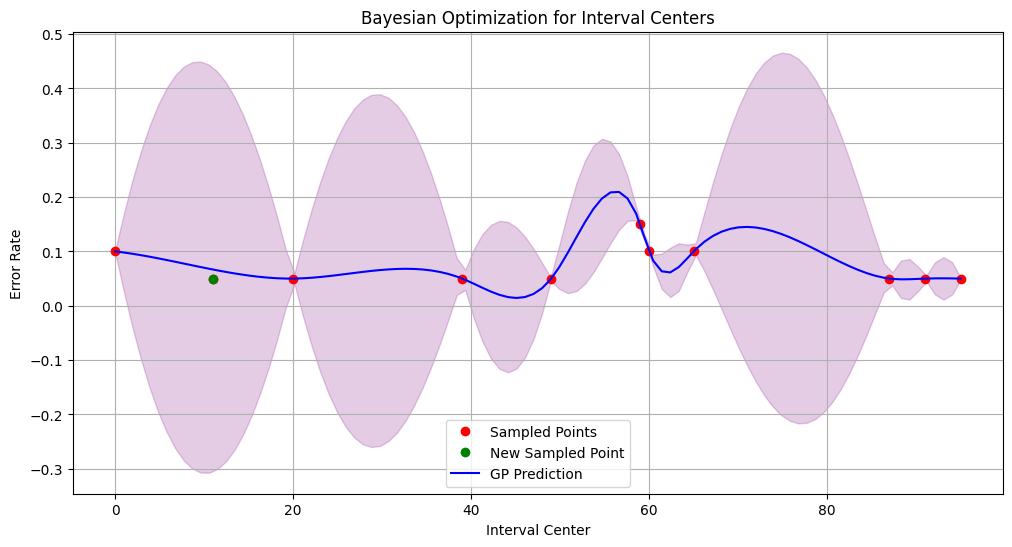

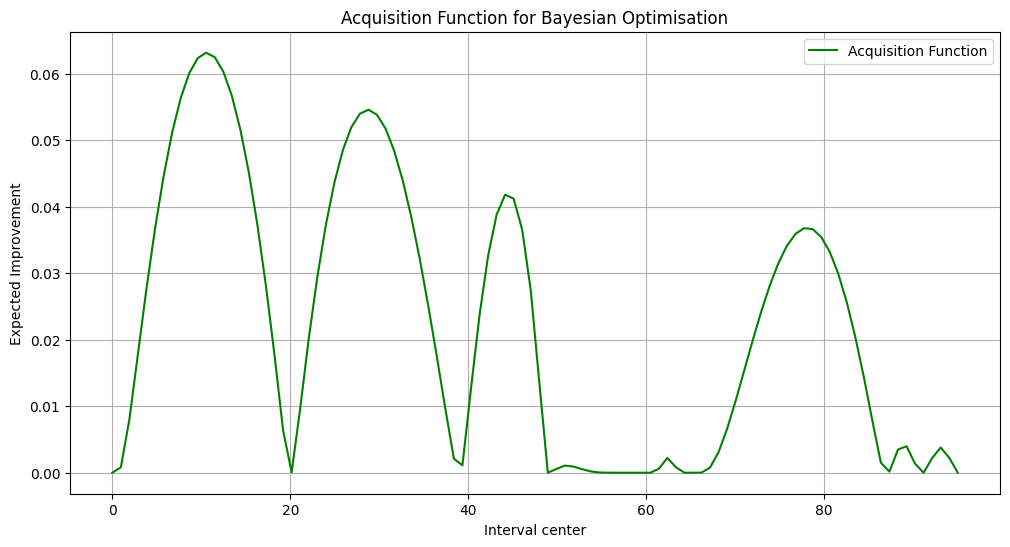

Iteration 2: New Interval Center = 29, Error Rate = 0.050000000000000044
Simple Regret Bound: 0.126009, Error Variance: 0.001024


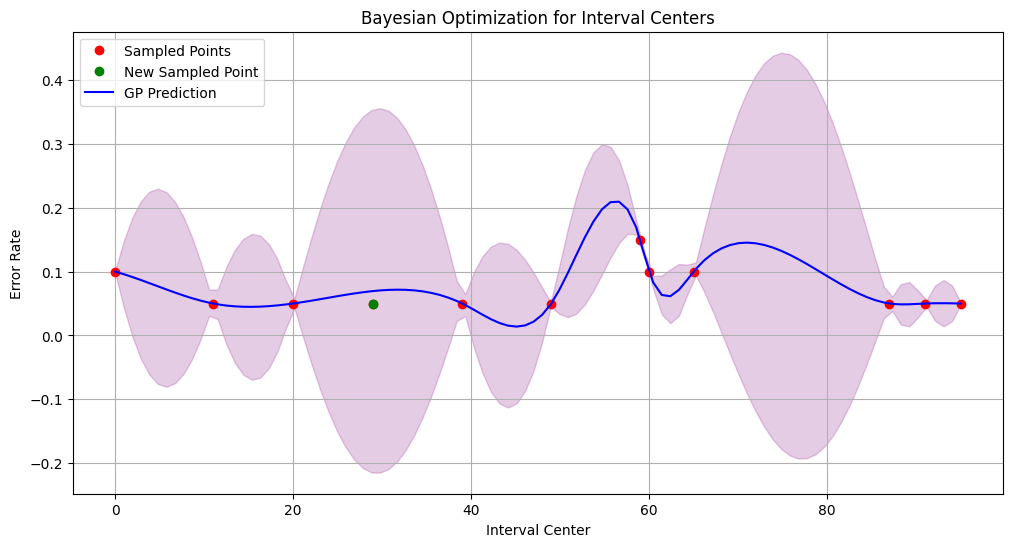

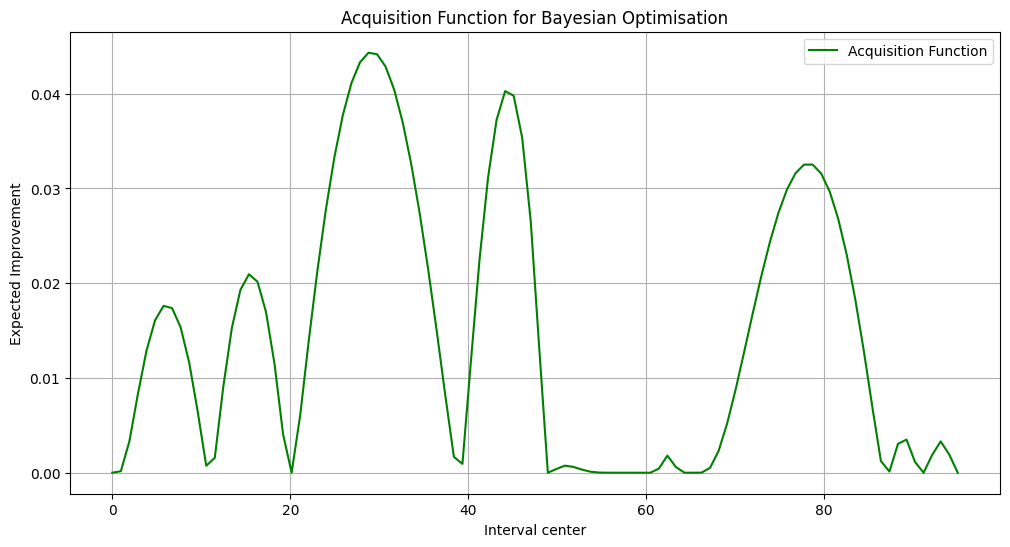

Iteration 3: New Interval Center = 45, Error Rate = 0.050000000000000044
Simple Regret Bound: 0.091456, Error Variance: 0.000976


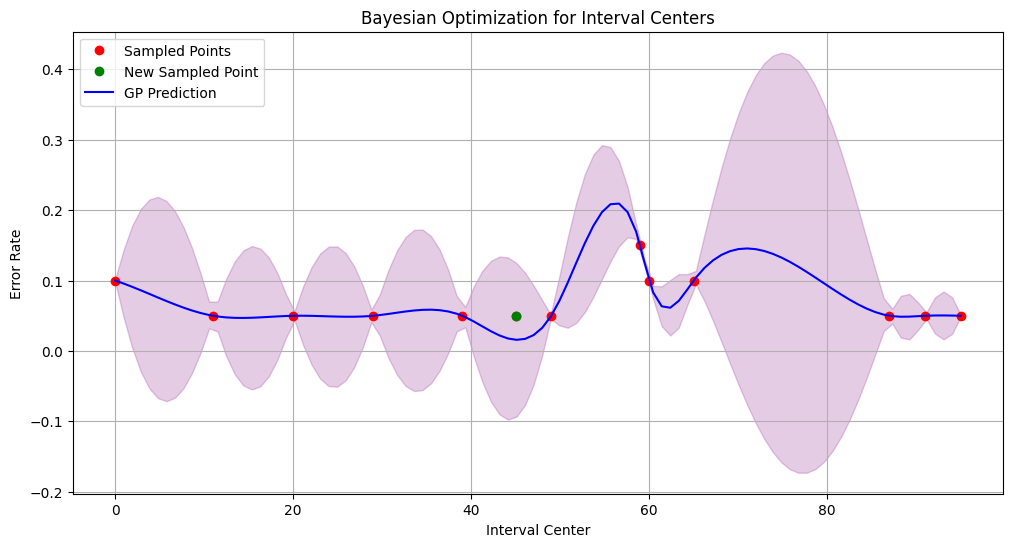

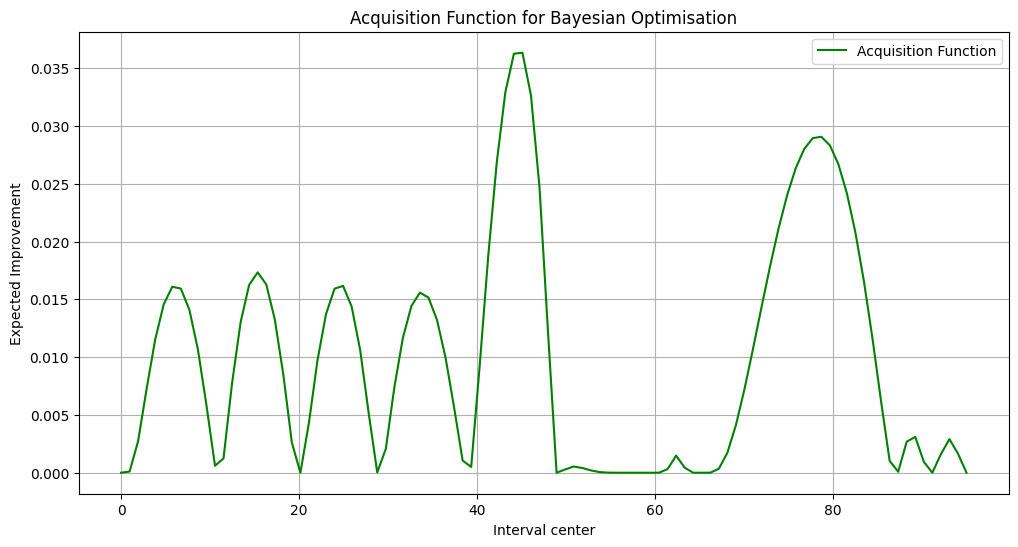

Iteration 4: New Interval Center = 78, Error Rate = 0.09999999999999998
Simple Regret Bound: 0.079982, Error Variance: 0.000969


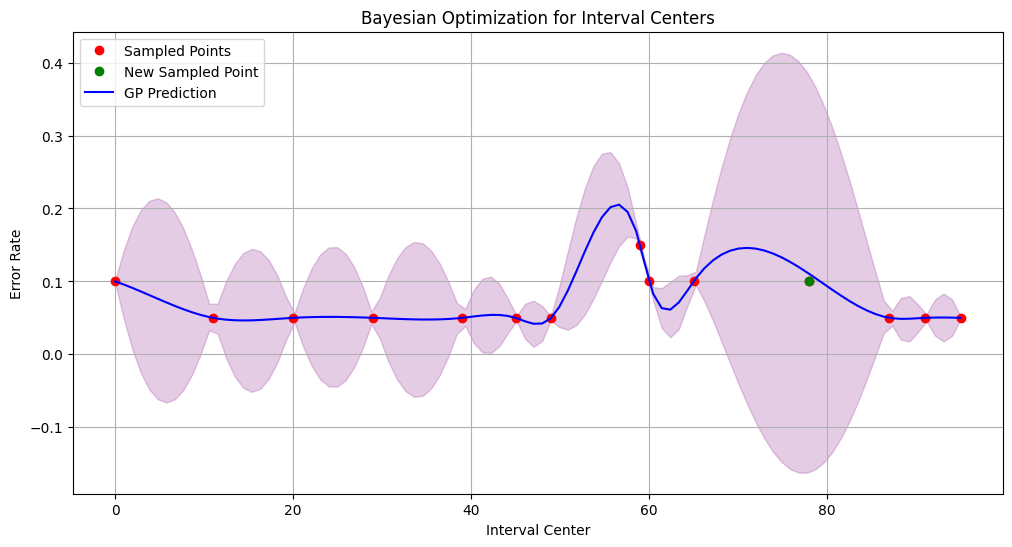

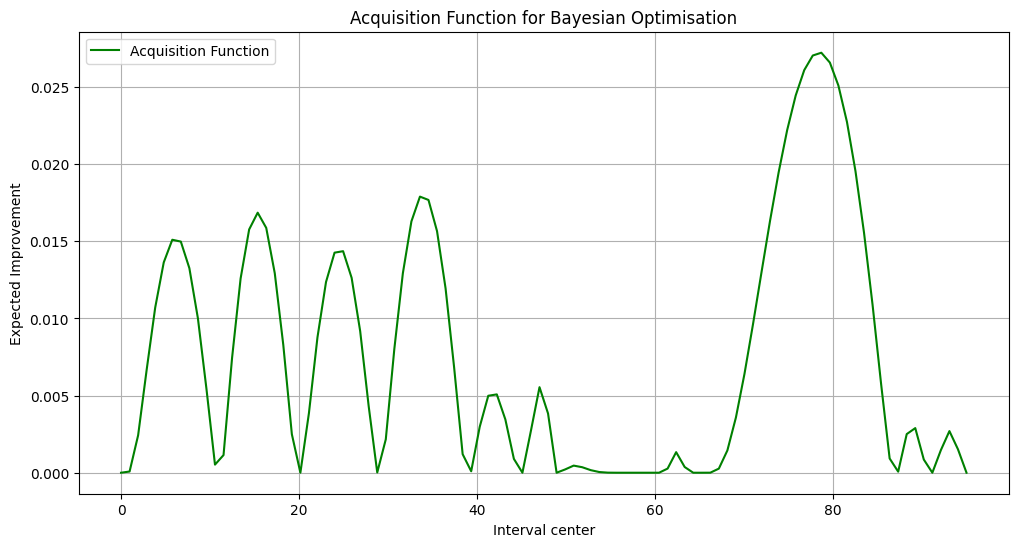

Iteration 5: New Interval Center = 34, Error Rate = 0.09999999999999998
Simple Regret Bound: 0.054121, Error Variance: 0.000956


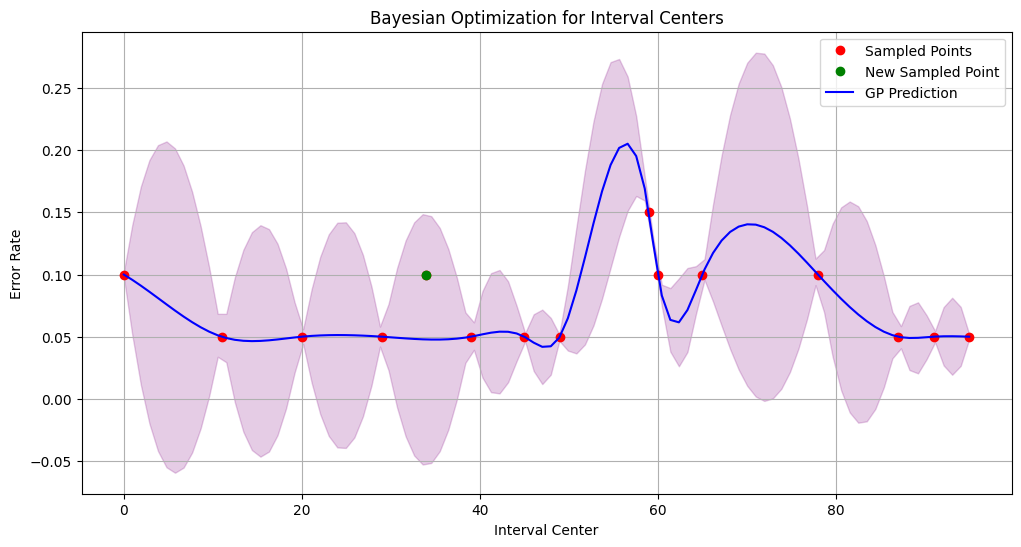

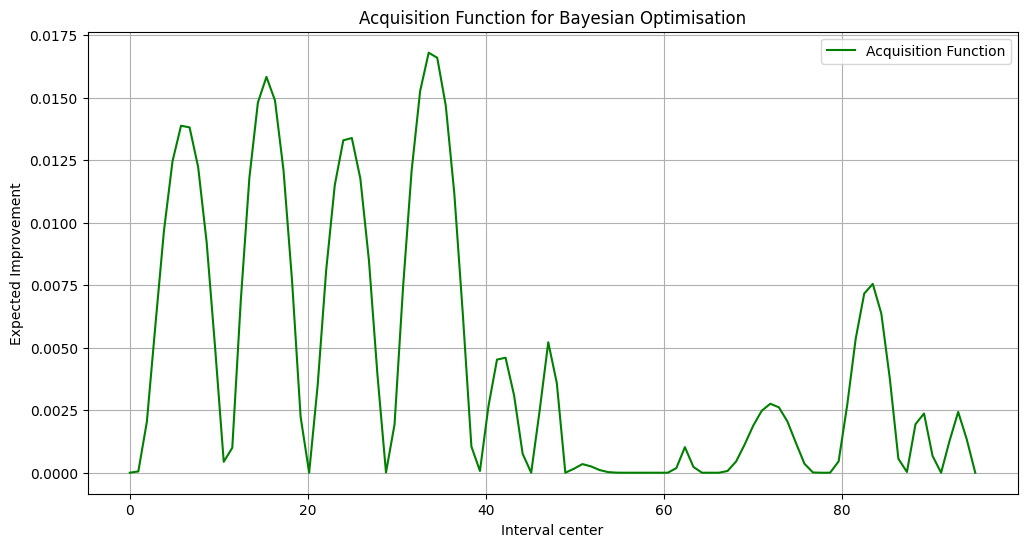

Iteration 6: New Interval Center = 25, Error Rate = 0.15000000000000002
Simple Regret Bound: 0.058876, Error Variance: 0.001240


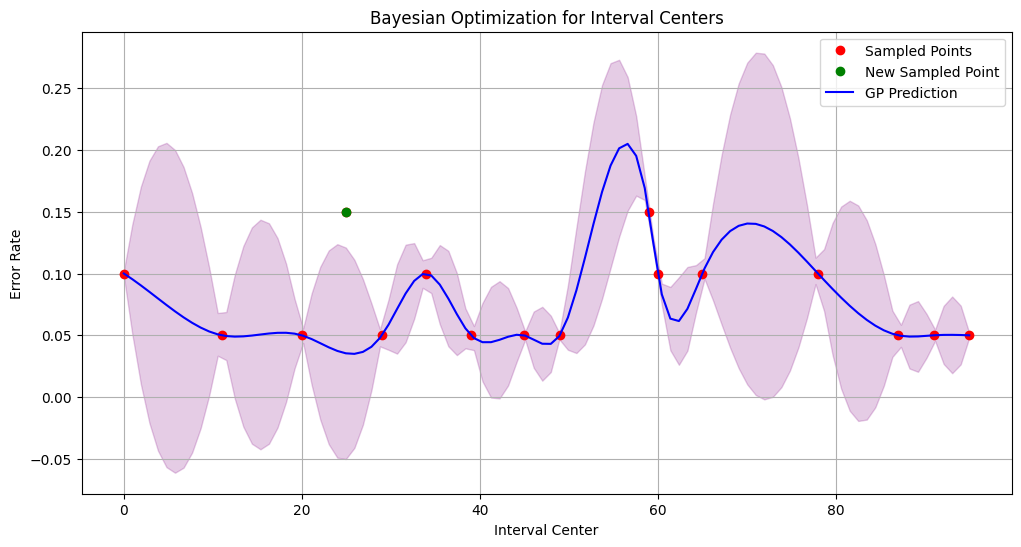

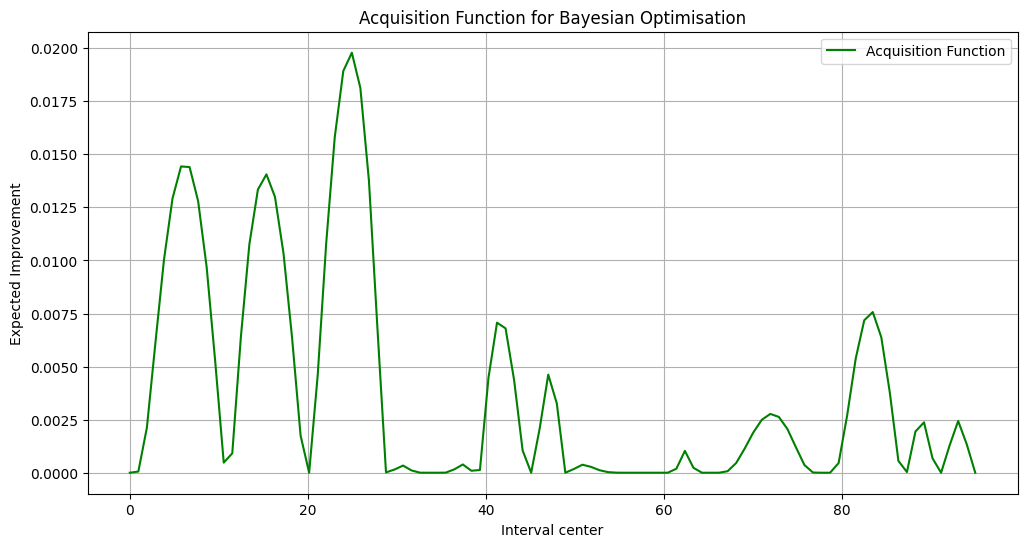

Iteration 7: New Interval Center = 16, Error Rate = 0.09999999999999998
Simple Regret Bound: 0.090957, Error Variance: 0.001194


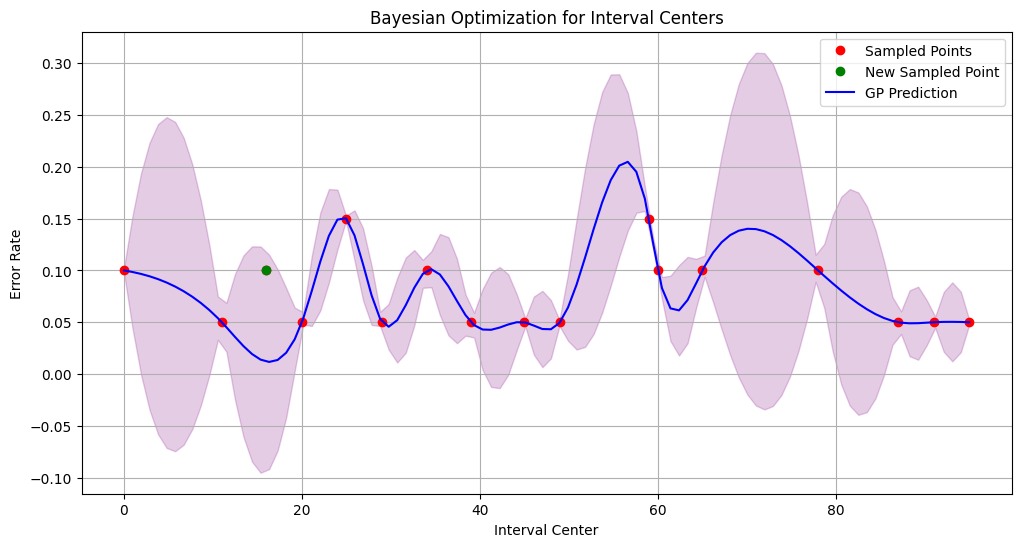

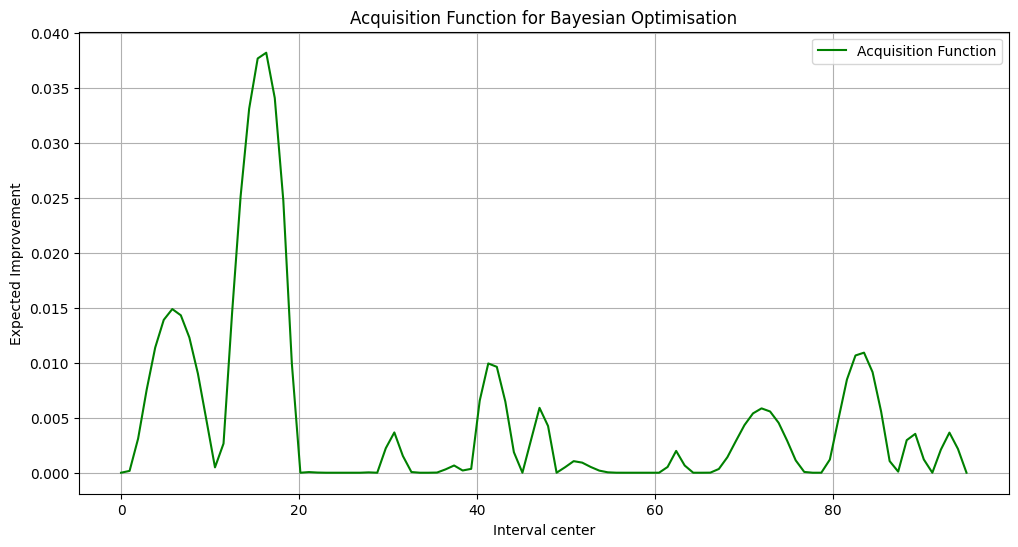

Iteration 8: New Interval Center = 6, Error Rate = 0.09999999999999998
Simple Regret Bound: 0.089314, Error Variance: 0.001150


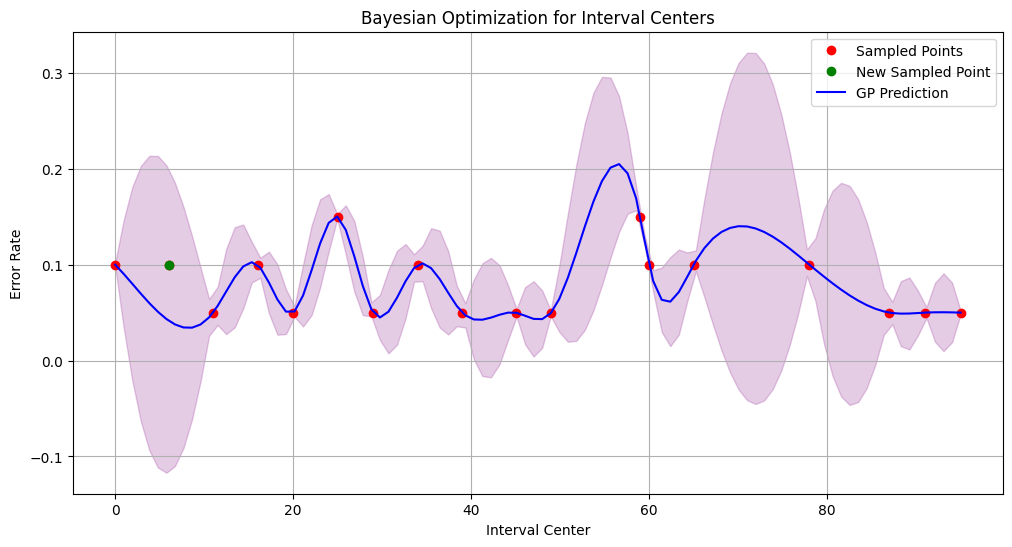

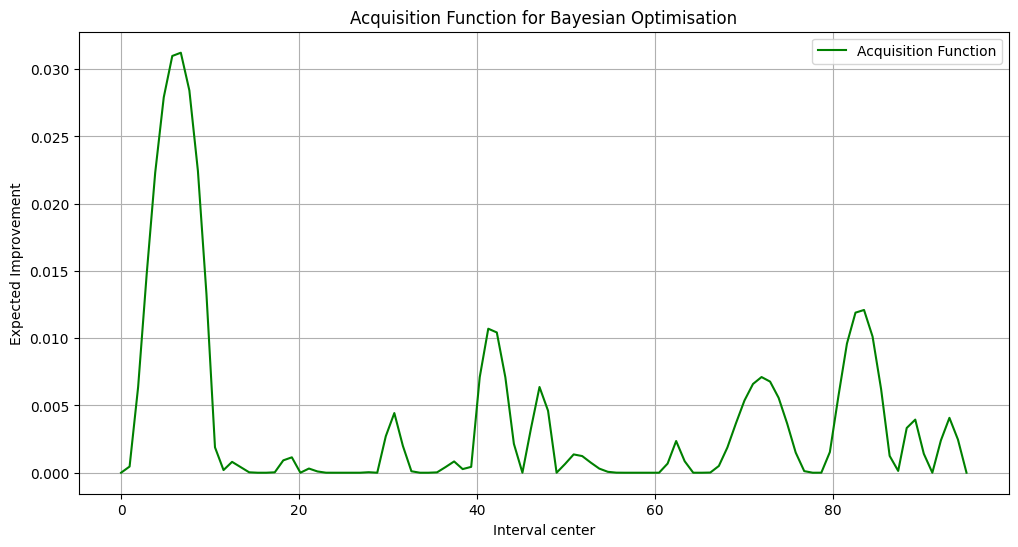

Iteration 9: New Interval Center = 83, Error Rate = 0.09999999999999998
Simple Regret Bound: 0.041394, Error Variance: 0.001108


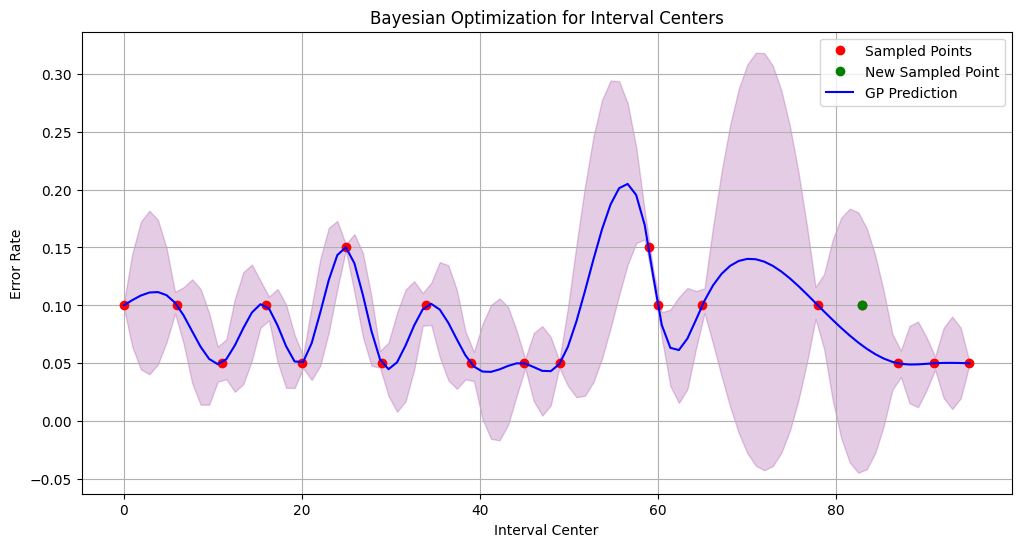

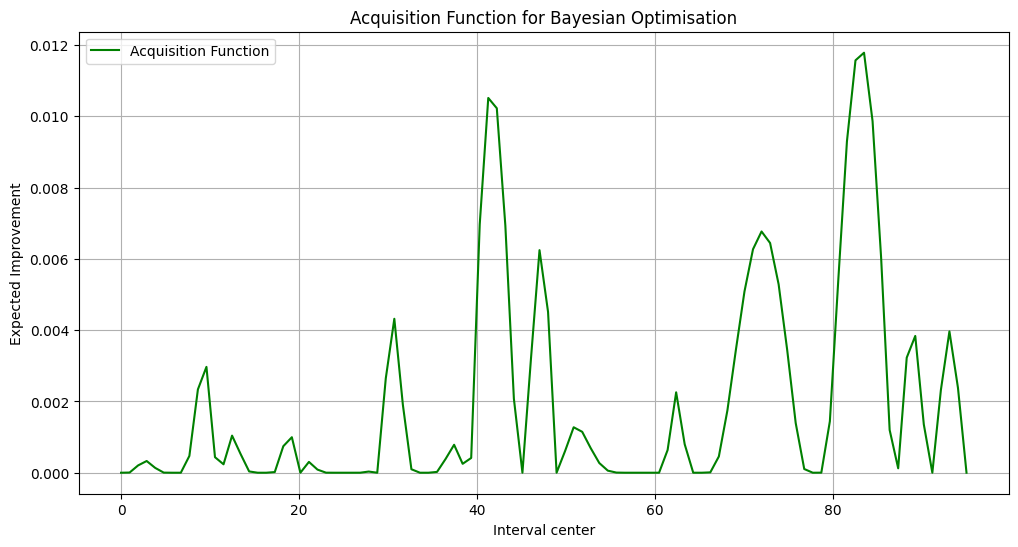

Iteration 10: New Interval Center = 42, Error Rate = 0.09999999999999998
Simple Regret Bound: 0.037105, Error Variance: 0.001069


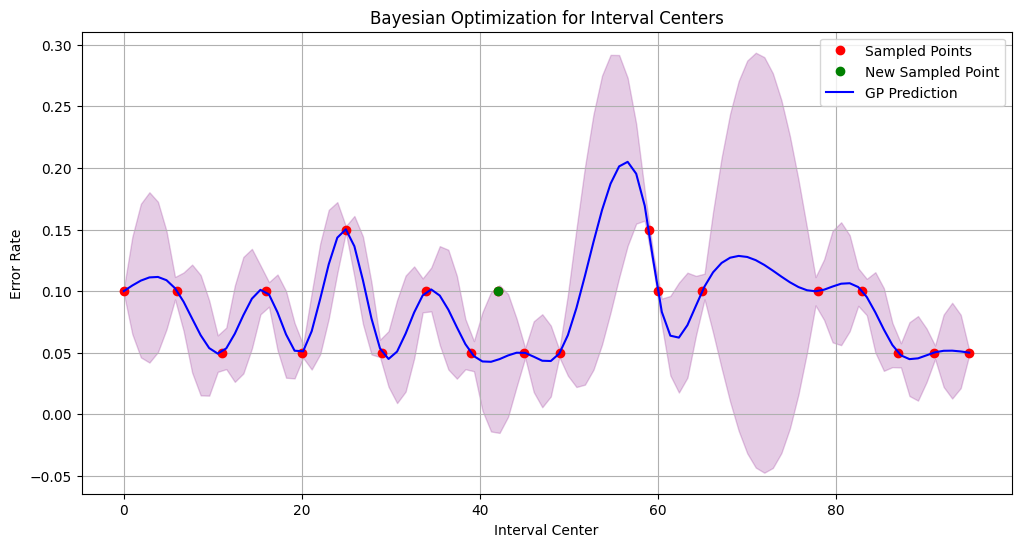

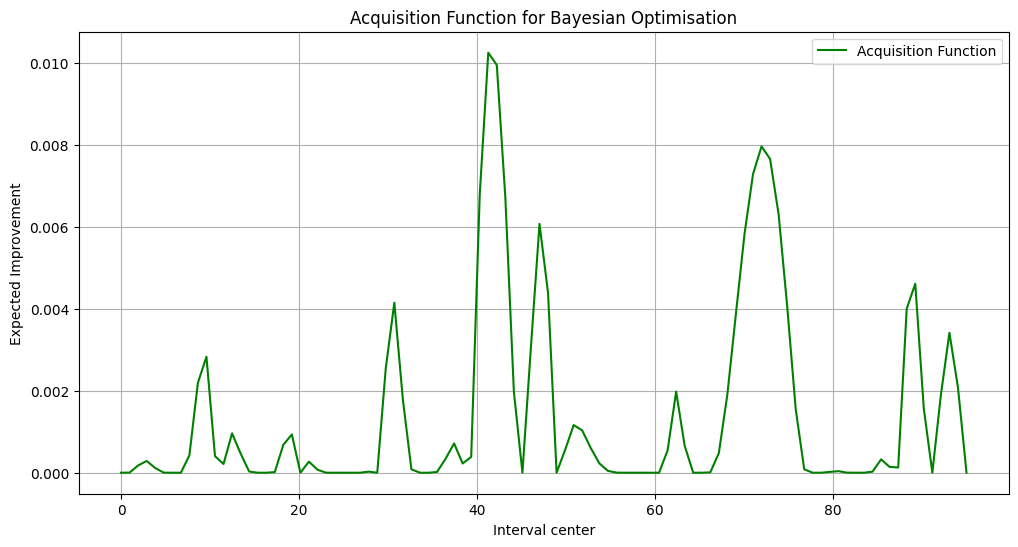

Iteration 11: New Interval Center = 47, Error Rate = 0.15000000000000002
Simple Regret Bound: 0.037606, Error Variance: 0.001224


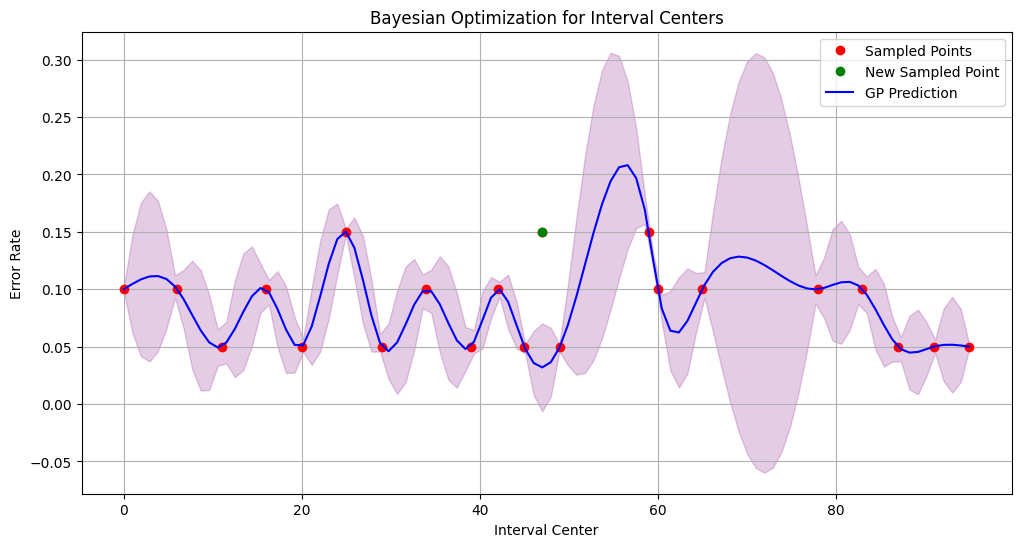

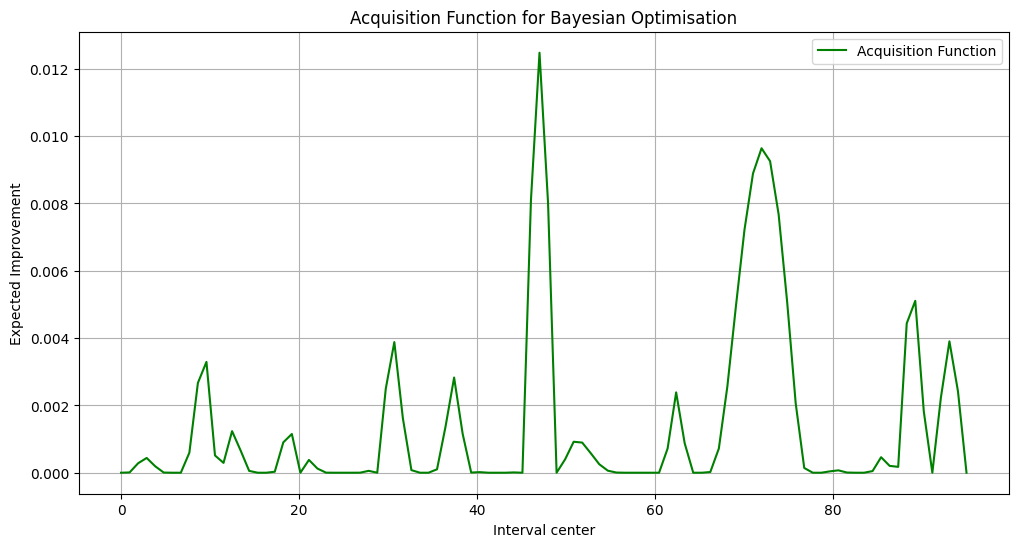

Iteration 12: New Interval Center = 51, Error Rate = 0.050000000000000044
Simple Regret Bound: 0.111082, Error Variance: 0.001224


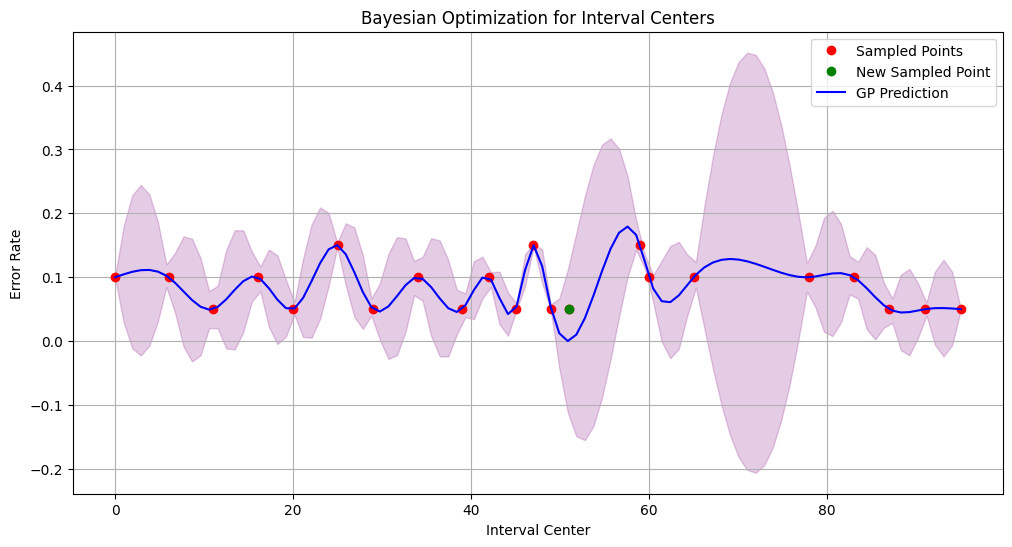

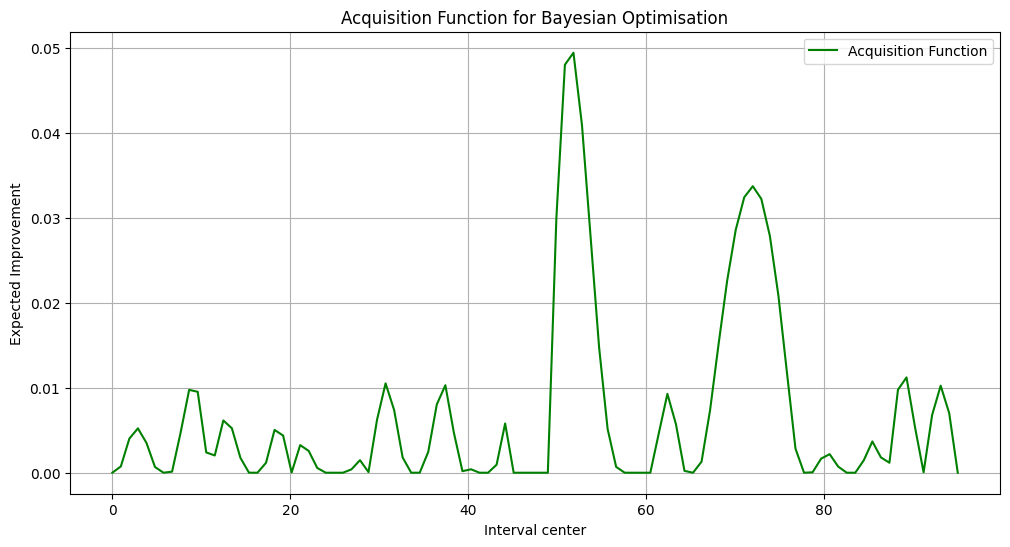

Iteration 13: New Interval Center = 72, Error Rate = 0.050000000000000044
Simple Regret Bound: 0.090096, Error Variance: 0.001219


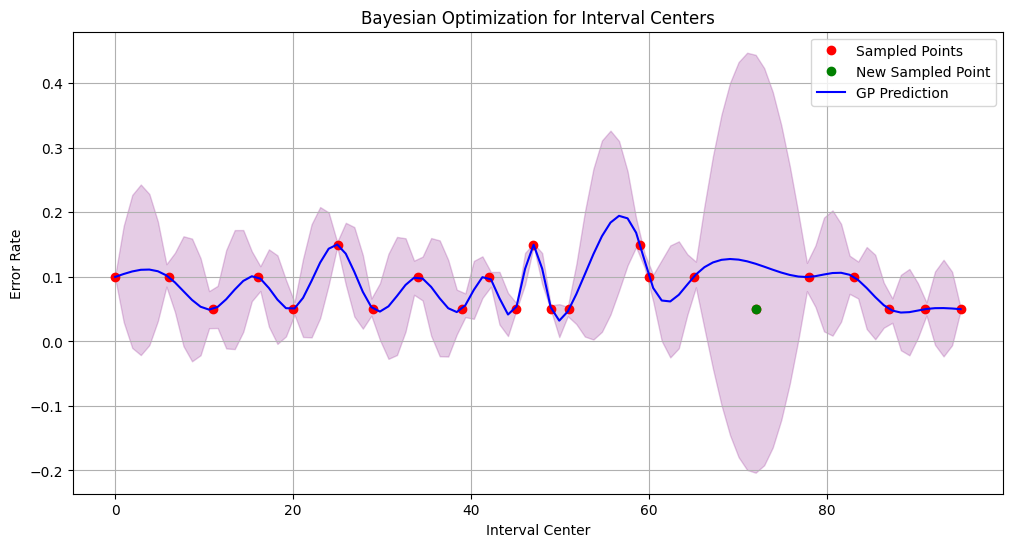

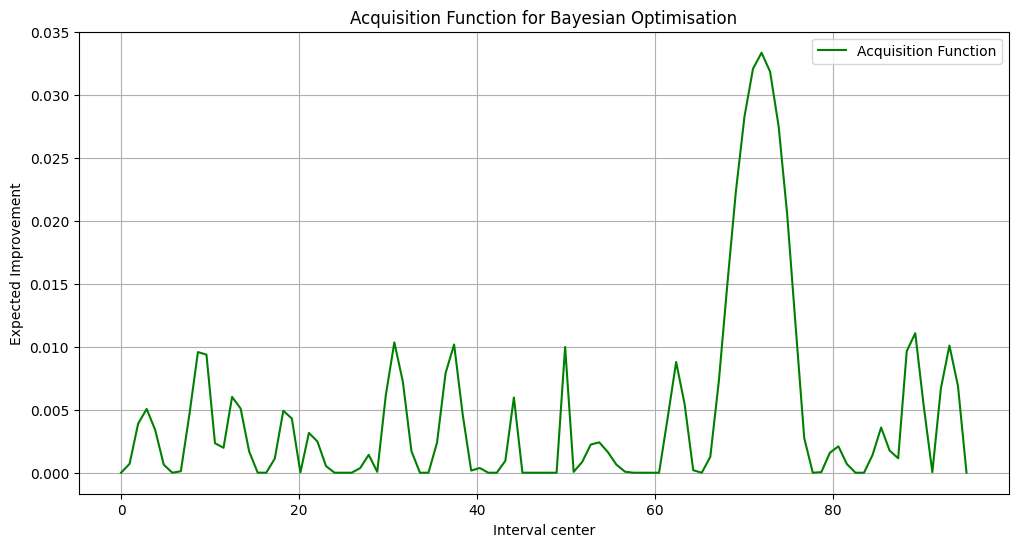

Iteration 14: New Interval Center = 74, Error Rate = 0.09999999999999998
Simple Regret Bound: 0.041359, Error Variance: 0.001181


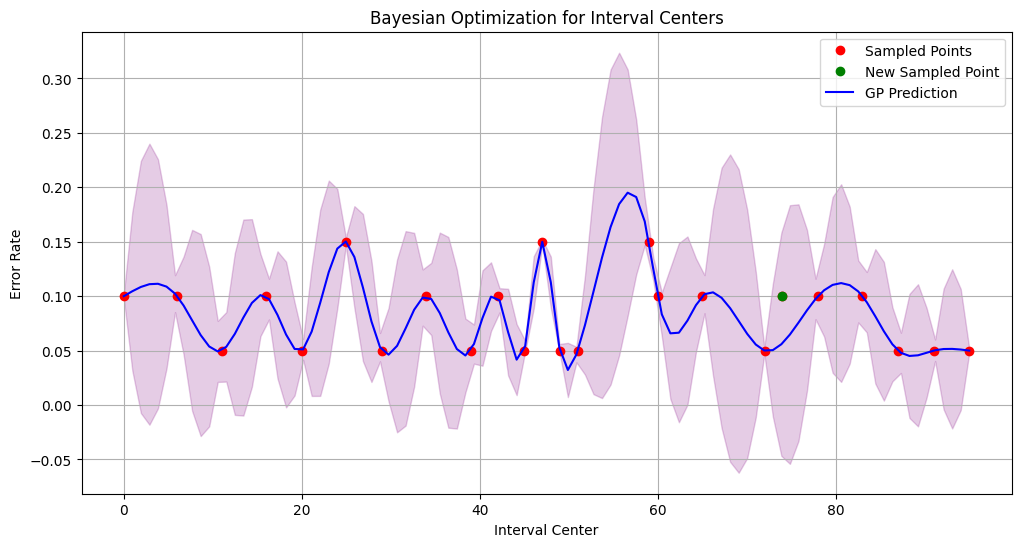

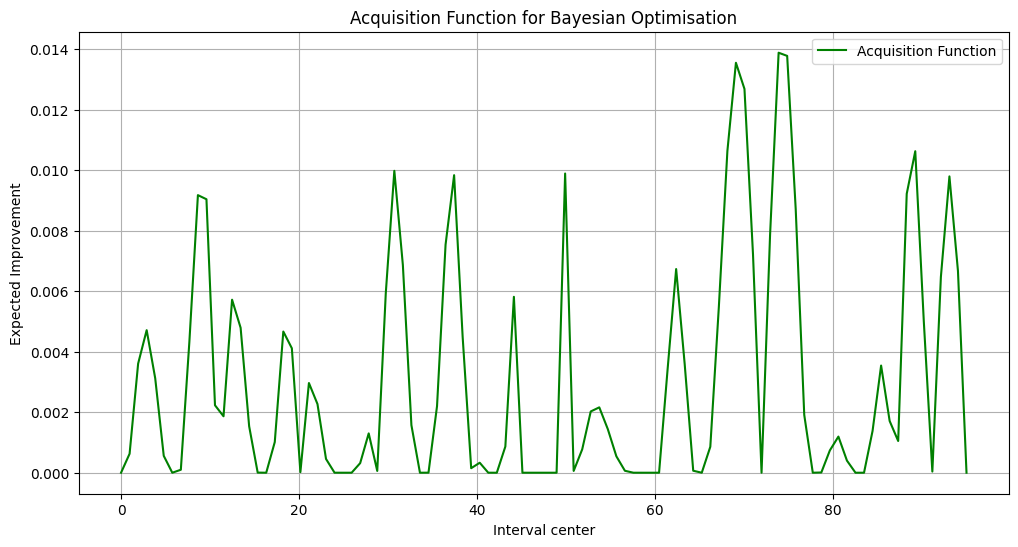

Iteration 15: New Interval Center = 69, Error Rate = 0.050000000000000044
Simple Regret Bound: 0.055401, Error Variance: 0.001176


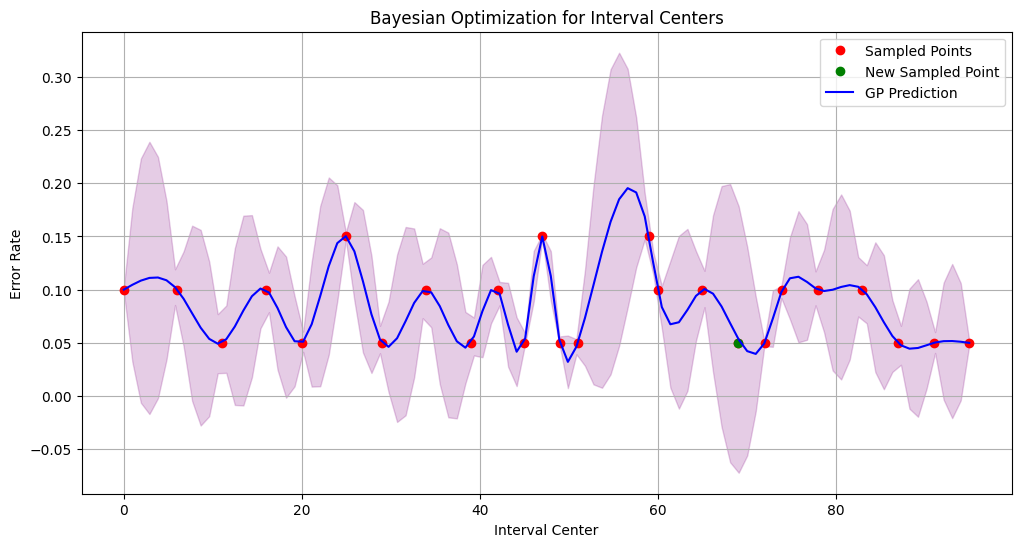

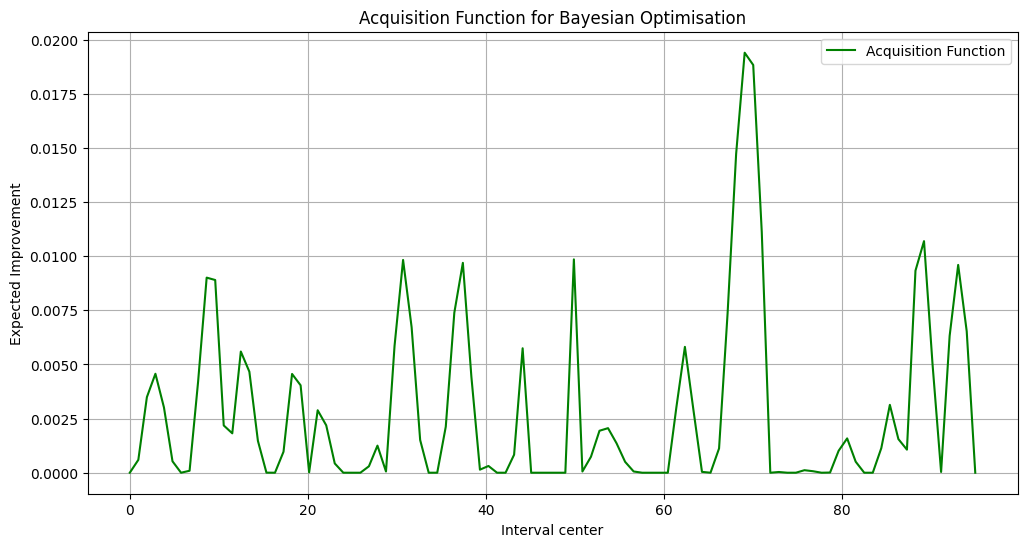

Iteration 16: New Interval Center = 89, Error Rate = 0.09999999999999998
Simple Regret Bound: 0.031266, Error Variance: 0.001143
 Termination Condition Met: Stopping Bayesian Optimization.

 Best Interval Found:
Center: 20  →  Interval: [0, 96)
 Interval Error Rate: 0.0500
 Full Signal Error Rate: 0.0500


In [ ]:
#CNN ECG data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

#  CNN definition
class Improved1DCNN(nn.Module):
    def __init__(self, input_length, num_classes=2):
        super(Improved1DCNN, self).__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),

            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # [batch, 1, length]
        return self.network(x)

#  Define training function for CNN on an interval
def train_nn(patient_data, labels, center, interval_width):
    start = max(0, center - interval_width // 2)
    end = min(patient_data.shape[1], center + interval_width // 2)

    x = patient_data[:, start:end].astype(np.float32)
    y = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

    model = Improved1DCNN(input_length=x.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(20):  #  Increase training time
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).numpy()
    return 1 - accuracy_score(y_test, preds)

#  Full model comparison on the entire signal
def train_full_nn(patient_data, labels):
    x = patient_data.astype(np.float32)
    y = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

    model = Improved1DCNN(input_length=x.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(20):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).numpy()
    return 1 - accuracy_score(y_test, preds)

# === Start of main script ===

# Example data (replace this with your actual train_data load)
# train_data = np.load("your_data.npy")
labels = train_data[:, 0]
patient_data = train_data[:, 1:]

interval_width = 200  # Increased from 10

edge_points = [0, patient_data.shape[1] - 1]
remaining_points = np.setdiff1d(np.arange(patient_data.shape[1]), edge_points)
random_points = np.random.choice(remaining_points, size=8, replace=False)
sampled_centers = np.concatenate([edge_points, random_points])

nn_results = [{"Interval center": c, "Error Rate": train_nn(patient_data, labels, c, interval_width)} for c in sampled_centers]
nn_df = pd.DataFrame(nn_results).sort_values(by="Interval center")

x_sample = np.array(nn_df["Interval center"]).reshape(-1, 1)
y_sample = np.array(nn_df["Error Rate"]).reshape(-1, 1)
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

def expected_improvement(x, x_sample, y_sample, gp, xi=0.01):
    mu, sigma = gp.predict(x, return_std=True)
    mu_sample_opt = np.min(y_sample)
    with np.errstate(divide="ignore"):
        z = (mu_sample_opt - mu - xi) / sigma
        ei = (mu_sample_opt - mu - xi) * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma == 0.0] = 0.0
    return ei

def bayesian_sample_one_point(x_sample, y_sample, gp, bounds, tried_points):
    x_candidates = np.arange(int(bounds[0]), int(bounds[1]) + 1).reshape(-1, 1)
    ei_values = expected_improvement(x_candidates, x_sample, y_sample, gp).ravel()
    ei_values_masked = np.copy(ei_values)
    for i, x in enumerate(x_candidates.ravel()):
        if x in tried_points:
            ei_values_masked[i] = -np.inf
    if np.all(ei_values_masked == -np.inf):
        return None
    best_idx = np.argmax(ei_values_masked)
    return int(x_candidates[best_idx][0])

def estimate_variance(error_rates):
    return np.var(error_rates)

iteration = 0
while iteration < 50:
    iteration += 1
    gp.fit(x_sample, y_sample)
    bounds = (0, patient_data.shape[1] - 1)
    tried_points = set(nn_df["Interval center"])
    new_center = bayesian_sample_one_point(x_sample, y_sample, gp, bounds, tried_points)
    if new_center is None:
        break
    new_error_rate = train_nn(patient_data, labels, new_center, interval_width)
    nn_df = pd.concat([nn_df, pd.DataFrame([{"Interval center": new_center, "Error Rate": new_error_rate}])]).drop_duplicates(keep='first')

    x = np.linspace(bounds[0], bounds[1], 100).reshape(-1, 1)
    mu, sigma = gp.predict(x, return_std=True)
    simple_regret_bound = np.min(mu + 1 * sigma) - np.min(mu - 1 * sigma)
    error_var = estimate_variance(nn_df["Error Rate"])

    print(f"Iteration {iteration}: New Interval Center = {new_center}, Error Rate = {new_error_rate}")
    print(f"Simple Regret Bound: {simple_regret_bound:.6f}, Error Variance: {error_var:.6f}")

    if simple_regret_bound <= np.sqrt(error_var):
        print(" Termination Condition Met: Stopping Bayesian Optimization.")
        break

    x_sample = np.array(nn_df["Interval center"]).reshape(-1, 1)
    y_sample = np.array(nn_df["Error Rate"]).reshape(-1, 1)

    plt.figure(figsize=(12, 6))
    plt.plot(x_sample, y_sample, "ro", label="Sampled Points")
    plt.plot(new_center, new_error_rate, "go", label="New Sampled Point")
    plt.plot(x, mu, "b-", label="GP Prediction")
    plt.fill_between(x.ravel(), mu - 1.96 * sigma, mu + 1.96 * sigma, alpha=0.2, color="purple")
    plt.xlabel("Interval Center")
    plt.ylabel("Error Rate")
    plt.title("Bayesian Optimization for Interval Centers")
    plt.legend()
    plt.grid(True)
    plt.show()

    ei_values = expected_improvement(x, x_sample, y_sample, gp)
    plt.figure(figsize=(12,6))
    plt.plot(x, ei_values, "g-", label="Acquisition Function")
    plt.xlabel("Interval center")
    plt.ylabel("Expected Improvement")
    plt.title("Acquisition Function for Bayesian Optimisation")
    plt.legend()
    plt.grid(True)
    plt.show()

#  Print best result and full model comparison
best_row = nn_df.loc[nn_df["Error Rate"].idxmin()]
best_center = int(best_row["Interval center"])
best_error = float(best_row["Error Rate"])
best_start = max(0, best_center - interval_width // 2)
best_end = min(patient_data.shape[1], best_center + interval_width // 2)

full_error = train_full_nn(patient_data, labels)

print("\n Best Interval Found:")
print(f"Center: {best_center}  →  Interval: [{best_start}, {best_end})")
print(f" Interval Error Rate: {best_error:.4f}")
print(f" Full Signal Error Rate: {full_error:.4f}")


In [203]:
#CNN AI data
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# Load data
with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])
y = y[:x.shape[0]]  # Trim y to match x if necessary

# Subsets (optional, not used directly in model training)
ai_data = x[y == 0]
human_data = x[y == 1]

# Define the CNN model
class Simple1DCNN(nn.Module):
    def __init__(self, input_length, num_classes=2):
        super(Simple1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

# Helper to get a sub-interval
def get_sampled_interval(data, center, width):
    start = max(0, center - width // 2)
    end = min(data.shape[1], center + width // 2)
    return start, end

# Train CNN on a specific interval
def train_nn(data, labels, center, width):
    start, end = get_sampled_interval(data, center, width)
    x = data[:, start:end].astype(np.float32)
    y = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
    model = Simple1DCNN(input_length=x.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).numpy()
    return 1 - accuracy_score(y_test, preds)

# Train CNN on full feature window
def train_full_nn(data, labels):
    x = data.astype(np.float32)
    y = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
    model = Simple1DCNN(input_length=x.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).numpy()
    return 1 - accuracy_score(y_test, preds)

# Initialise Bayesian Optimisation
interval_width = 40
n_initial = 10
center_bounds = (0, x.shape[1] - 1)
initial_centers = np.random.choice(np.arange(center_bounds[0], center_bounds[1]), size=n_initial, replace=False)
x_sample = initial_centers.reshape(-1, 1)
y_sample = np.array([train_nn(x, y, c, interval_width) for c in initial_centers]).reshape(-1, 1)

# Expected Improvement function
def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Bayesian Optimisation loop
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)
max_iter = 30

for _ in range(max_iter):
    gp.fit(x_sample, y_sample)
    grid = np.arange(center_bounds[0], center_bounds[1] + 1).reshape(-1, 1)
    tried = set(x_sample.ravel())
    grid = np.array([pt for pt in grid if pt[0] not in tried])
    if len(grid) == 0:
        break

    ei = expected_improvement(grid, x_sample, y_sample, gp)
    best_idx = np.argmax(ei)
    next_point = grid[best_idx][0]
    new_error = train_nn(x, y, next_point, interval_width)
    x_sample = np.vstack((x_sample, [[next_point]]))
    y_sample = np.append(y_sample, [[new_error]])

# Extract best interval result
best_idx = np.argmin(y_sample)
best_center = int(x_sample[best_idx][0])
best_start, best_end = get_sampled_interval(x, best_center, interval_width)
best_error = float(y_sample[best_idx])

full_model_error = train_full_nn(x, y)

print(" Best interval center:", best_center)
print(" Best interval range:  ({} to {})".format(best_start, best_end))
print(" Best interval error:  {:.4f}".format(best_error))
print(" Full model error:     {:.4f}".format(full_model_error))




 Best interval center: 183
 Best interval range:  (163 to 203)
 Best interval error:  0.3025
 Full model error:     0.4750


x shape: (2000, 512)
y shape: (3000,)


In [40]:
#parametrised width MLP simulated data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

# Simulate loading ECG200_TRAIN for demonstration
from sklearn.datasets import make_classification
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=96, n_informative=10, n_classes=2)
y = 2 * y - 1  # match labels -1 and 1 as in ECG200

# Set bounds
center_bounds = (0, X.shape[1] - 1)
width_bounds = (4, min(30, X.shape[1]))

# Function to compute start and end indices from center and width
def get_sampled_interval(data, center, width):
    start = max(0, int(center - width // 2))
    end = min(data.shape[1], int(center + width // 2))
    return start, end

# Train NN and return error rate
def train_nn(data, labels, center, width):
    start, end = get_sampled_interval(data, center, width)
    x = data[:, start:end]
    x_train, x_test, y_train, y_test = train_test_split(x, labels, test_size=0.2, random_state=42, stratify=labels)
    nn_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
    nn_model.fit(x_train, y_train)
    y_pred = nn_model.predict(x_test)
    return 1 - accuracy_score(y_test, y_pred)

# Expected improvement acquisition function
def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Generate initial random samples
n_initial = 10
initial_centers = np.random.randint(center_bounds[0], center_bounds[1], size=n_initial)
initial_widths = np.random.randint(width_bounds[0], width_bounds[1], size=n_initial)
X_sample = np.column_stack([initial_centers, initial_widths])
Y_sample = np.array([train_nn(X, y, c, w) for c, w in X_sample])

# Bayesian Optimisation loop
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

n_iter = 30
for i in range(n_iter):
    gp.fit(X_sample, Y_sample)
    
    grid = np.array([[c, w] for c in range(center_bounds[0], center_bounds[1]+1)
                            for w in range(width_bounds[0], width_bounds[1]+1)])
    tried = set(map(tuple, X_sample))
    grid = np.array([pt for pt in grid if tuple(pt) not in tried])
    
    if len(grid) == 0:
        break
    
    ei = expected_improvement(grid, X_sample, Y_sample, gp)
    best_idx = np.argmax(ei)
    next_point = grid[best_idx]
    
    new_error = train_nn(X, y, next_point[0], next_point[1])
    X_sample = np.vstack((X_sample, next_point))
    Y_sample = np.append(Y_sample, new_error)

# Extract best result
best_idx = np.argmin(Y_sample)
best_center, best_width = X_sample[best_idx]
best_start, best_end = get_sampled_interval(X, best_center, best_width)
best_error = Y_sample[best_idx]

results_df = pd.DataFrame({
    'Center': X_sample[:, 0],
    'Width': X_sample[:, 1],
    'Error Rate': Y_sample
})

# Print results to console
print("\nBayesian Optimisation Results (sampled center-width pairs with error rates):")
print(results_df)

print("\nBest Interval Found:")
print(f"Center     : {best_center}")
print(f"Width      : {best_width}")
print(f"Interval   : [{best_start}, {best_end})")
print(f"Error Rate : {best_error:.4f}")



c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDri


Bayesian Optimisation Results (sampled center-width pairs with error rates):
    Center  Width  Error Rate
0       37     27       0.375
1        2      9       0.475
2       45     20       0.275
3       21     26       0.375
4       32     16       0.375
5       31     26       0.400
6       16     25       0.275
7       81     20       0.450
8       55     24       0.200
9        2     19       0.600
10      59      4       0.475
11      95     30       0.600
12      63     30       0.275
13      18      4       0.200
14      95      4       0.450
15      52     30       0.275
16      17     12       0.250
17      25      4       0.450
18      13      4       0.475
19      63     18       0.300
20      77      4       0.500
21      53     18       0.200
22      19      7       0.400
23      16     18       0.325
24      10     30       0.300
25      44      4       0.500
26      75     30       0.375
27      51     22       0.250
28      57     20       0.400
29      50     14     


 Bayesian Optimisation Results:
    Center  Width  Error Rate
24      90     36        0.00
2       66     33        0.05
23      86     31        0.05
21      95     40        0.05
22      87     40        0.05

 Best Interval Found:
Center     : 90
Width      : 36
Interval   : [72, 96)
Error Rate : 0.0000


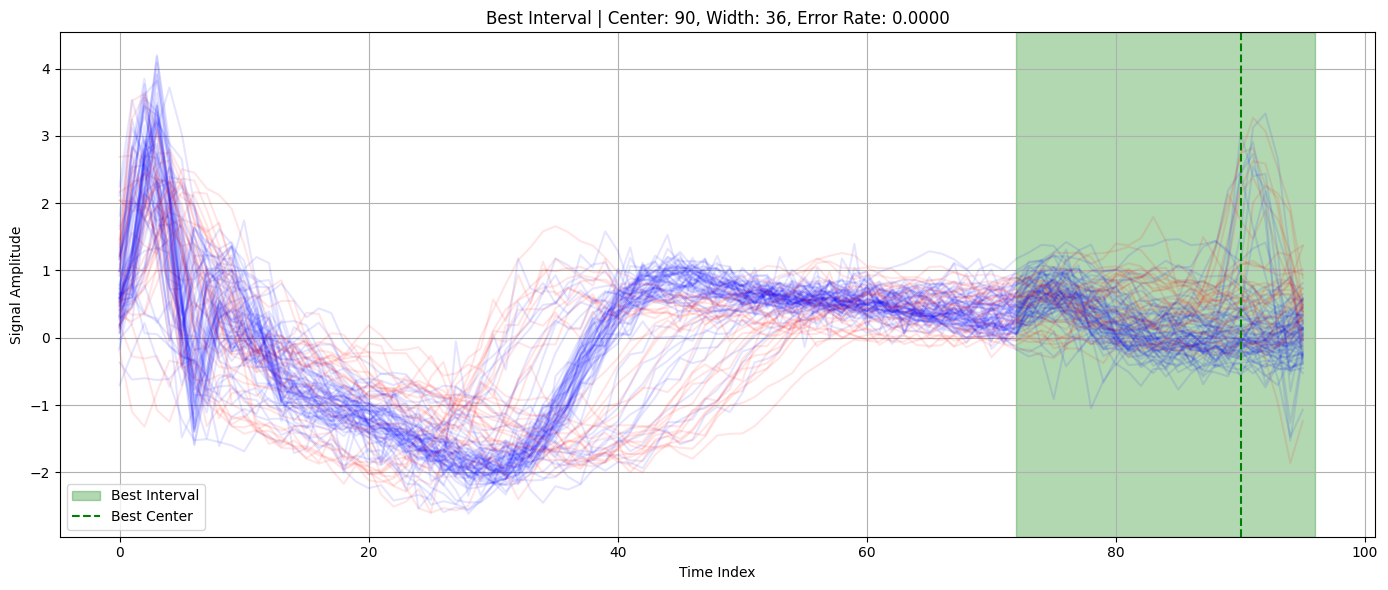

In [204]:
#parmetrised width CNN ECG data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Improved CNN definition
class Improved1DCNN(nn.Module):
    def __init__(self, input_length, num_classes=2):
        super(Improved1DCNN, self).__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),

            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        return self.network(x)

# Compute interval from center and width
def get_sampled_interval(data, center, width):
    start = max(0, int(center - width // 2))
    end = min(data.shape[1], int(center + width // 2))
    return start, end

# Train CNN on an interval
def train_nn(patient_data, labels, center, width):
    start, end = get_sampled_interval(patient_data, center, width)
    if end - start < 4:  # Prevent training on too-short intervals
        return 1.0

    x = patient_data[:, start:end].astype(np.float32)
    y = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
    model = Improved1DCNN(input_length=x.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(20):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).numpy()
    return 1 - accuracy_score(y_test, preds)

# Expected improvement function
def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# === Main trial on real ECG data ===

labels = train_data[:, 0]
patient_data = train_data[:, 1:]

center_bounds = (0, patient_data.shape[1] - 1)
width_bounds = (4, min(40, patient_data.shape[1]))

# Initial sampling
n_initial = 10
initial_centers = np.random.randint(center_bounds[0], center_bounds[1], size=n_initial)
initial_widths = np.random.randint(width_bounds[0], width_bounds[1], size=n_initial)
X_sample = np.column_stack([initial_centers, initial_widths])
Y_sample = np.array([train_nn(patient_data, labels, c, w) for c, w in X_sample])

# GP setup
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

# Bayesian Optimisation loop
n_iter = 30
for i in range(n_iter):
    gp.fit(X_sample, Y_sample)

    # Grid of unexplored (center, width) pairs
    grid = np.array([[c, w] for c in range(center_bounds[0], center_bounds[1]+1)
                             for w in range(width_bounds[0], width_bounds[1]+1)])
    tried = set(map(tuple, X_sample))
    grid = np.array([pt for pt in grid if tuple(pt) not in tried])

    if len(grid) == 0:
        break

    ei = expected_improvement(grid, X_sample, Y_sample, gp)
    best_idx = np.argmax(ei)
    next_point = grid[best_idx]
    new_error = train_nn(patient_data, labels, next_point[0], next_point[1])

    X_sample = np.vstack((X_sample, next_point))
    Y_sample = np.append(Y_sample, new_error)

# Extract best result
best_idx = np.argmin(Y_sample)
best_center, best_width = X_sample[best_idx]
best_start, best_end = get_sampled_interval(patient_data, best_center, best_width)
best_error = Y_sample[best_idx]

# Final report
results_df = pd.DataFrame({
    'Center': X_sample[:, 0],
    'Width': X_sample[:, 1],
    'Error Rate': Y_sample
})

print("\n Bayesian Optimisation Results:")
print(results_df.sort_values(by="Error Rate").head())

print("\n Best Interval Found:")
print(f"Center     : {best_center}")
print(f"Width      : {best_width}")
print(f"Interval   : [{best_start}, {best_end})")
print(f"Error Rate : {best_error:.4f}")

# Plot
plt.figure(figsize=(14, 6))

for i in range(features.shape[0]):
    color = "blue" if labels[i] == 1 else "red"
    plt.plot(features[i], color=color, alpha=0.1)

# Overlay the best interval
plt.axvspan(best_start, best_end, color="green", alpha=0.3, label="Best Interval")
plt.axvline(best_center, color="green", linestyle="--", label="Best Center")

plt.title(f"Best Interval | Center: {int(best_center)}, Width: {int(best_width)}, Error Rate: {best_error:.4f}")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Iteration 1: center=0, width=50, error=0.3675
Iteration 2: center=209, width=50, error=0.3150
Iteration 3: center=0, width=4, error=1.0000
Iteration 4: center=104, width=50, error=0.4450
Iteration 5: center=175, width=50, error=0.3775
Iteration 6: center=278, width=50, error=0.4125
Iteration 7: center=511, width=50, error=0.4225
Iteration 8: center=195, width=4, error=0.3650
Iteration 9: center=38, width=50, error=0.3550
Iteration 10: center=352, width=50, error=0.4925
Iteration 11: center=200, width=34, error=0.3575
Iteration 12: center=224, width=50, error=0.3550
Iteration 13: center=155, width=4, error=0.3575
Iteration 14: center=200, width=50, error=0.3750
Iteration 15: center=224, width=4, error=0.3325
Iteration 16: center=144, width=50, error=0.4250
Iteration 17: center=442, width=50, error=0.4875
Iteration 18: center=347, width=4, error=0.4525
Iteration 19: center=64, width=50, error=0.3750
Iteration 20: center=119, width=4, error=0.3800
Iteration 21: center=213, width=44, error

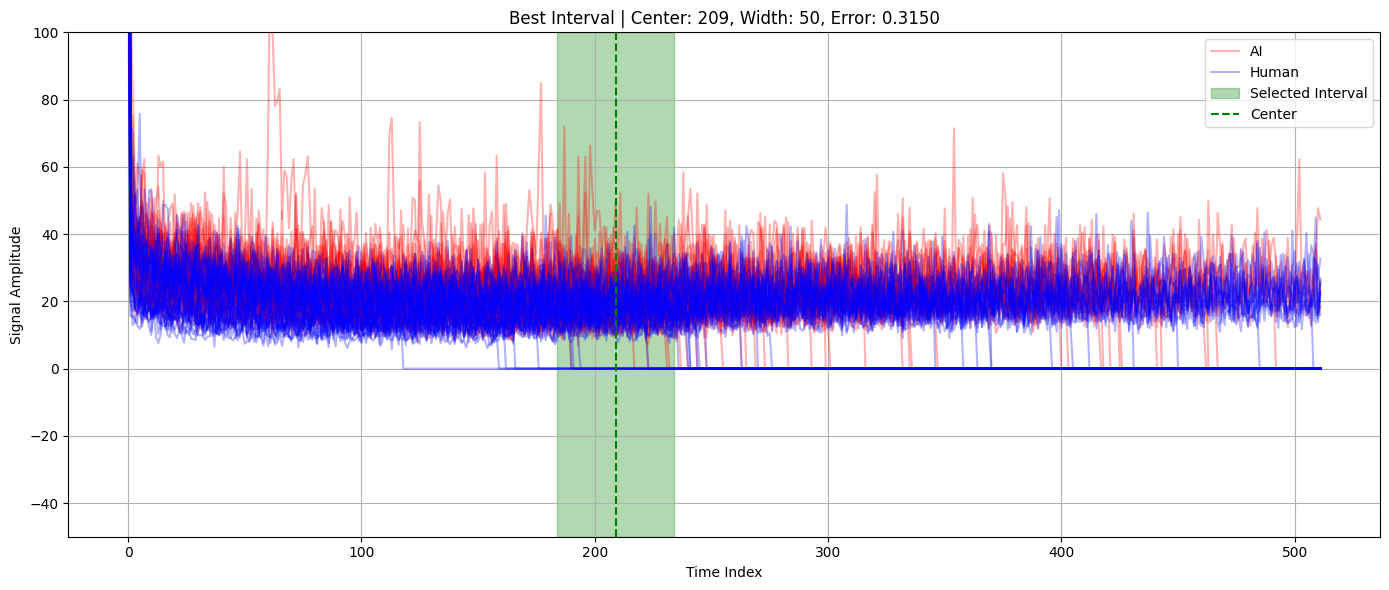

In [92]:
#parametrised width MLP AI data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import pickle

# Load your data here
x = np.array(data["x"], dtype=np.float64)
y = np.array(data["y"])

# Remove rows with NaNs
tokeep = set(range(x.shape[0])).difference(set(np.where(np.isnan(x))[0]))
x = x[list(tokeep)]
y = y[list(tokeep)]

# Parameter bounds
center_bounds = (0, x.shape[1] - 1)
width_bounds = (4, min(50, x.shape[1]))  # You can change 40 to something else if needed

# Sampling initial points
n_initial = 10
initial_centers = np.random.randint(center_bounds[0], center_bounds[1], size=n_initial)
initial_widths = np.random.randint(width_bounds[0], width_bounds[1], size=n_initial)
x_sample = np.column_stack([initial_centers, initial_widths])

# Define interval extractor
def get_sampled_interval(x, center, width):
    start = max(0, center - width // 2)
    end = min(x.shape[1], center + width // 2)
    return start, end

# Train on an interval
def train_nn(x, y, center, width):
    start, end = get_sampled_interval(x, center, width)
    if end - start < 4:
        return 1.0
    x_interval = x[:, start:end]
    X_train, X_test, y_train, y_test = train_test_split(x_interval, y, test_size=0.2, random_state=42, stratify=y)
    model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return 1 - accuracy_score(y_test, y_pred)

#  Full data evaluation
def train_full_nn(x, y):
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
    model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return 1 - accuracy_score(y_test, y_pred)

# Evaluate initial samples
y_sample = np.array([train_nn(x, y, c, w) for c, w in x_sample])

# GP and acquisition setup
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide="warn"):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Bayesian Optimisation Loop
iteration = 0
max_iter = 50
while iteration < max_iter:
    iteration += 1
    gp.fit(x_sample, y_sample)

    grid = np.array([[c, w] for c in range(center_bounds[0], center_bounds[1] + 1)
                            for w in range(width_bounds[0], width_bounds[1] + 1)])
    tried = set(map(tuple, x_sample))
    grid = np.array([pt for pt in grid if tuple(pt) not in tried])
    if len(grid) == 0:
        break

    ei = expected_improvement(grid, x_sample, y_sample, gp)
    best_idx = np.argmax(ei)
    next_center, next_width = grid[best_idx]
    new_error = train_nn(x, y, next_center, next_width)

    x_sample = np.vstack((x_sample, [next_center, next_width]))
    y_sample = np.append(y_sample, new_error)

    print(f"Iteration {iteration}: center={next_center}, width={next_width}, error={new_error:.4f}")

# Extract best result
best_idx = np.argmin(y_sample)
best_center, best_width = x_sample[best_idx]
best_start, best_end = get_sampled_interval(x, best_center, best_width)
best_error = y_sample[best_idx]

#  Full-data model error
full_error = train_full_nn(x, y)

#  Final report
print("\n Best Interval Found:")
print(f"Center     : {best_center}")
print(f"Width      : {best_width}")
print(f"Interval   : [{best_start}, {best_end})")
print(f"Interval Error Rate : {best_error:.4f}")
print(f"Full Signal Error Rate: {full_error:.4f}")

import matplotlib.pyplot as plt
import numpy as np

# Compute the interval start and end
def get_sampled_interval(data, center, width):
    start = max(0, int(center - width // 2))
    end = min(data.shape[1], int(center + width // 2))
    return start, end

best_start, best_end = get_sampled_interval(x, best_center, best_width)

np.random.seed(42)
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
sample_0 = np.random.choice(idx_0, size=40, replace=False)
sample_1 = np.random.choice(idx_1, size=40, replace=False)

# Plot the sampled signals
plt.figure(figsize=(14, 6))

for i in sample_0:
    plt.plot(x[i], color="red", alpha=0.3, label="AI" if i == sample_0[0] else "")
for i in sample_1:
    plt.plot(x[i], color="blue", alpha=0.3, label="Human" if i == sample_1[0] else "")

# Add interval highlighting
plt.axvspan(best_start, best_end, color="green", alpha=0.3, label="Selected Interval")
plt.axvline(best_center, color="green", linestyle="--", label="Center")

plt.title(f"Best Interval | Center: {best_center}, Width: {best_width}, Error: {best_error:.4f}")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.ylim(-50, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Best center = 141
Best width = 40
Best interval = (121, 161)
Best error rate = 0.2700
Full model error rate = 0.4100


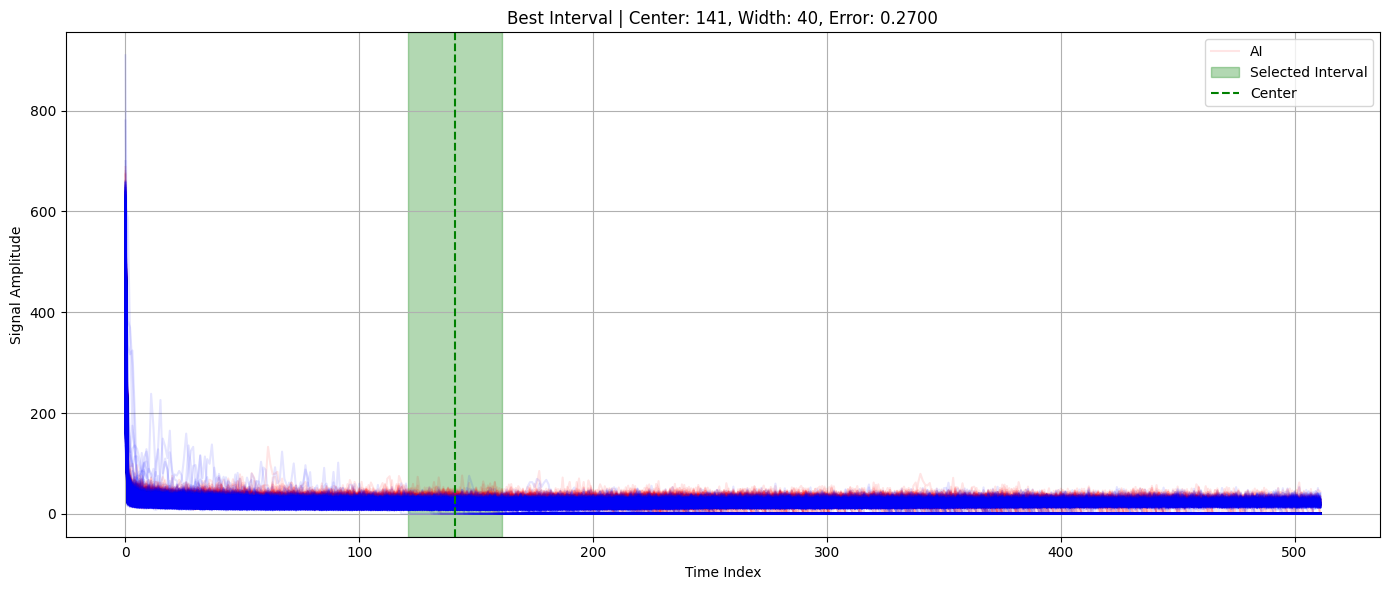

In [ ]:
#parametrised width CNN AI data
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import matplotlib.pyplot as plt

# Load your ECG data (assumes 'data' is defined elsewhere)
x = np.array(data['x'])
y = np.array(data['y'])
y = y[:x.shape[0]]  # Ensure matching shape

# Define CNN
class Simple1DCNN(nn.Module):
    def __init__(self, input_length, num_classes=2):
        super(Simple1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

# Interval selector
def get_sampled_interval(data, center, width):
    start = max(0, center - width // 2)
    end = min(data.shape[1], center + width // 2)
    return start, end

# CNN training for interval
def train_nn(data, labels, center, width):
    start, end = get_sampled_interval(data, center, width)
    x_interval = data[:, start:end].astype(np.float32)
    y_bin = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x_interval, y_bin, test_size=0.2, stratify=y_bin, random_state=42)
    model = Simple1DCNN(input_length=x_interval.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).numpy()
    return 1 - accuracy_score(y_test, preds)

# Full model training
def train_full_nn(data, labels):
    x_full = data.astype(np.float32)
    y_bin = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x_full, y_bin, test_size=0.2, stratify=y_bin, random_state=42)
    model = Simple1DCNN(input_length=x_full.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).numpy()
    return 1 - accuracy_score(y_test, preds)

# Bayesian optimisation setup over both center and width
n_initial = 10
center_bounds = (0, x.shape[1] - 1)
width_bounds = (4, min(40, x.shape[1]))

initial_centers = np.random.randint(center_bounds[0], center_bounds[1], size=n_initial)
initial_widths = np.random.randint(width_bounds[0], width_bounds[1], size=n_initial)

x_sample = np.column_stack([initial_centers, initial_widths])
y_sample = np.array([train_nn(x, y, c, w) for c, w in zip(initial_centers, initial_widths)]).reshape(-1, 1)

def expected_improvement(X, X_sample, Y_sample, model, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu_sample_opt = np.min(Y_sample)
    with np.errstate(divide='warn'):
        imp = mu_sample_opt - mu - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Run BO
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)
max_iter = 30

for _ in range(max_iter):
    gp.fit(x_sample, y_sample)
    grid = np.array([[c, w] for c in range(center_bounds[0], center_bounds[1] + 1)
                            for w in range(width_bounds[0], width_bounds[1] + 1)])
    tried = set(map(tuple, x_sample))
    grid = np.array([pt for pt in grid if tuple(pt) not in tried])
    if len(grid) == 0:
        break

    ei = expected_improvement(grid, x_sample, y_sample, gp)
    best_idx = np.argmax(ei)
    next_center, next_width = grid[best_idx]
    new_error = train_nn(x, y, next_center, next_width)
    x_sample = np.vstack((x_sample, [[next_center, next_width]]))
    y_sample = np.append(y_sample, [[new_error]])

# Best interval result
best_idx = np.argmin(y_sample)
best_center, best_width = x_sample[best_idx]
best_start, best_end = get_sampled_interval(x, int(best_center), int(best_width))
best_error = float(y_sample[best_idx])

# Full model result
full_model_error = train_full_nn(x, y)

print(f"Best center = {int(best_center)}")
print(f"Best width = {int(best_width)}")
print(f"Best interval = ({best_start}, {best_end})")
print(f"Best error rate = {best_error:.4f}")
print(f"Full model error rate = {full_model_error:.4f}")





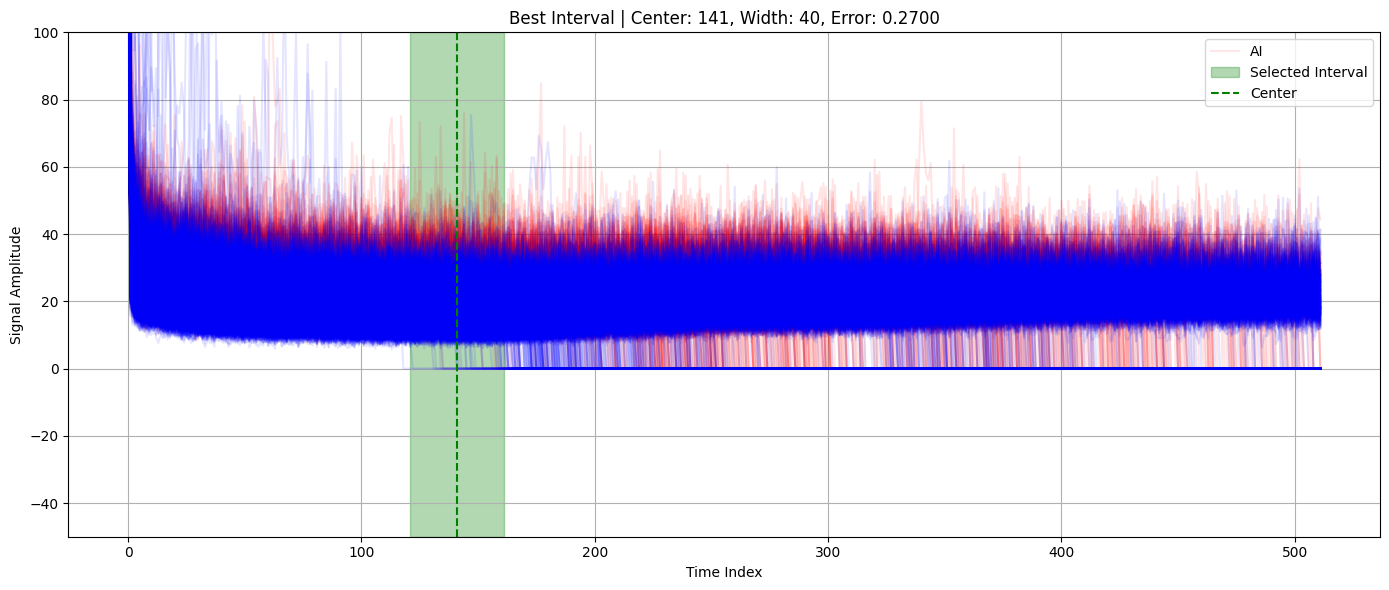

In [85]:
# Plot all signals with the best interval highlighted
plt.figure(figsize=(14, 6))

for i in range(x.shape[0]):
    if y[i] == 0:
        plt.plot(x[i], color="red", alpha=0.1, label="AI" if i == 0 else "")
    elif y[i] == 1:
        plt.plot(x[i], color="blue", alpha=0.1, label="Human" if i == 0 else "")

# Add the best interval overlay
plt.axvspan(best_start, best_end, color="green", alpha=0.3, label="Selected Interval")
plt.axvline(best_center, color="green", linestyle="--", label="Center")

plt.title(f"Best Interval | Center: {best_center}, Width: {best_width}, Error: {best_error:.4f}")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.ylim(-50, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


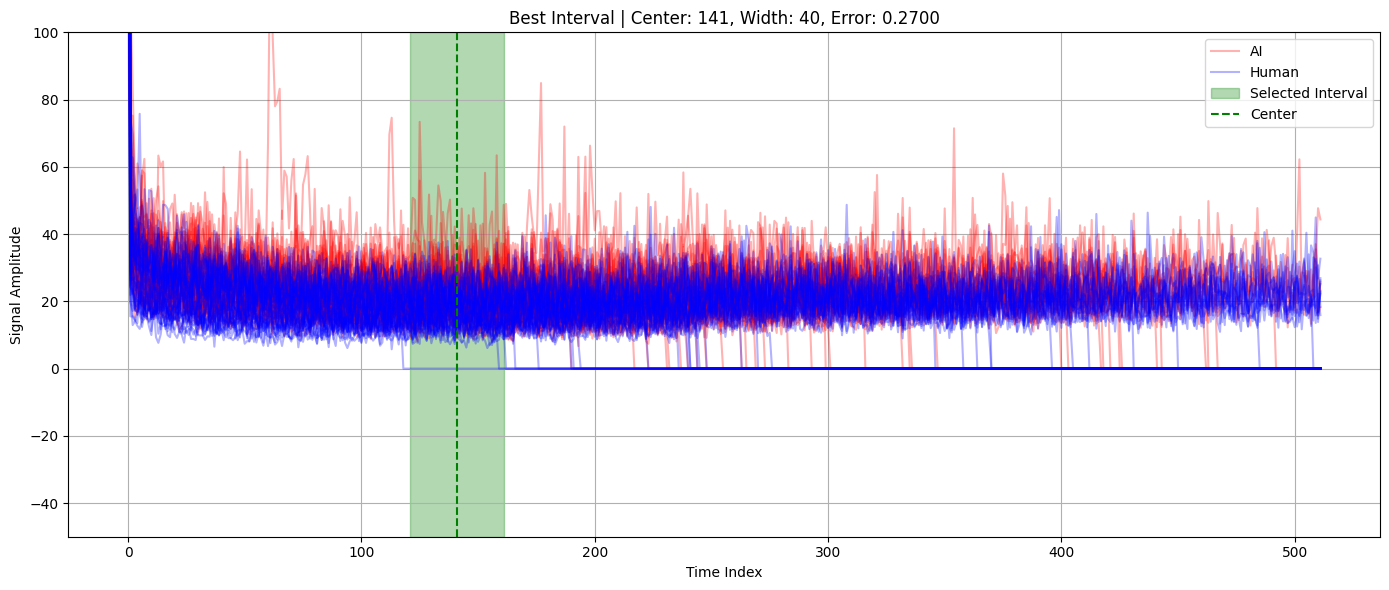

In [ ]:
# Sample a limited number of signals from each class for clearer visualisation
np.random.seed(42)
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
sample_0 = np.random.choice(idx_0, size=40, replace=False)
sample_1 = np.random.choice(idx_1, size=40, replace=False)

# Plot the sampled signals
plt.figure(figsize=(14, 6))

for i in sample_0:
    plt.plot(x[i], color="red", alpha=0.3, label="AI" if i == sample_0[0] else "")
for i in sample_1:
    plt.plot(x[i], color="blue", alpha=0.3, label="Human" if i == sample_1[0] else "")

# Add interval highlighting
plt.axvspan(best_start, best_end, color="green", alpha=0.3, label="Selected Interval")
plt.axvline(best_center, color="green", linestyle="--", label="Center")

plt.title(f"Best Interval | Center: {best_center}, Width: {best_width}, Error: {best_error:.4f}")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.ylim(-50, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Classification Report:
               precision    recall  f1-score   support

           0      0.801     0.769     0.785       199
           1      0.780     0.811     0.795       201

    accuracy                          0.790       400
   macro avg      0.790     0.790     0.790       400
weighted avg      0.790     0.790     0.790       400


Classification Report:
               precision    recall  f1-score   support

           0      0.801     0.769     0.785       199
           1      0.780     0.811     0.795       201

    accuracy                          0.790       400
   macro avg      0.790     0.790     0.790       400
weighted avg      0.790     0.790     0.790       400



c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


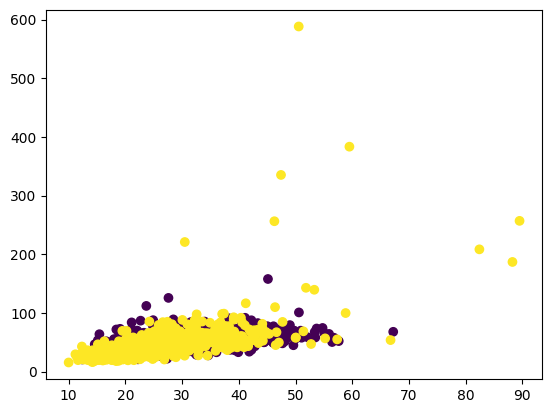

In [ ]:
#logistic regression from Antoine 
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn import preprocessing
import numpy as np
import matplotlib.pyplot as plt
with open('data (1).pkl', 'rb') as f:
    data = pickle.load(f)

#### Logistic regression
X = data['x']
tokeep = set(range(X.shape[0])).difference(set(np.where(np.isnan(X))[0]))
X = X[list(tokeep)]
y = np.array(data['y'])[list(tokeep)]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = preprocessing.StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model
mod_log = LogisticRegression()
mod_log.fit(np.nan_to_num(X_train), y_train)

# Make predictions
y_pred = mod_log.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('\nClassification Report:\n', classification_report(y_test, y_pred,digits = 3))

# Make predictions
tokeep = set(range(X_test.shape[0])).difference(set(np.where(np.isnan(X_test))[0]))
X_test = X_test[list(tokeep)]
y_test = np.array(y_test)[list(tokeep)]
y_pred = mod_log.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('\nClassification Report:\n', classification_report(y_test, y_pred,digits = 3))
plt.scatter(X[:,10],X[:,1],c = y)



In [58]:
import pickle
import pprint

obj = pickle.load(open("data_v2.pkl", "rb"))

with open("out 2.txt", "a") as f:
        pprint.pprint(obj, stream=f)


In [ ]:
#MLP ECG Data Lasso 
from group_lasso import GroupLasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd

# Parameters
interval_width = 20
stride = 1
X = patient_data  # already defined in your environment
y = labels        # already defined in your environment
n_samples, n_features = X.shape

# Build overlapping groups with unique IDs
grouped_features = []
groups = []

for start in range(0, n_features - interval_width + 1, stride):
    end = start + interval_width
    grouped_features.append((start, end))
    group_id = len(grouped_features) - 1  # unique ID
    groups.extend([group_id] * interval_width)

# Stack grouped intervals
X_grouped = np.hstack([X[:, start:end] for start, end in grouped_features])
groups = np.array(groups)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_grouped, y, test_size=0.2, random_state=42, stratify=y
)

# Fit Group Lasso
model = GroupLasso(
    groups=groups,
    group_reg=0.005,  # Adjusted regularisation
    l1_reg=0,
    frobenius_lipschitz=True,
    scale_reg="group_size",
    subsampling_scheme=1,
    supress_warning=True,
    n_iter=1000,
    tol=1e-4
)

model.fit(X_train, y_train)
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)
overall_error_rate = 1 - accuracy_score(y_test, y_pred)

# Group-wise norm
group_coefs = model.coef_.reshape(-1, interval_width)
group_norms = np.linalg.norm(group_coefs, axis=1)
nonzero_groups = np.where(group_norms > 1e-4)[0]

# Report selected intervals
print(f"🔍 Overall Error Rate (GroupLasso model): {overall_error_rate:.4f}")
print(f"✅ {len(nonzero_groups)} interval(s) selected by Group Lasso.")

if len(nonzero_groups) > 0:
    for idx in nonzero_groups:
        start, end = grouped_features[idx]
        print(f" - Selected Interval [{start}, {end})  (Norm: {group_norms[idx]:.4f})")
else:
    print("⚠️ No meaningful intervals selected. Try lowering regularisation.")

# Evaluate each selected interval independently
interval_errors = []
print("\n🔬 Evaluating selected intervals independently using MLPClassifier...")

for idx in nonzero_groups:
    start, end = grouped_features[idx]
    x_interval = X[:, start:end]

    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        x_interval, y, test_size=0.2, random_state=42, stratify=y
    )

    mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
    mlp.fit(X_train_i, y_train_i)
    y_pred_i = mlp.predict(X_test_i)
    error = 1 - accuracy_score(y_test_i, y_pred_i)

    interval_errors.append((start, end, error))
    print(f"   → Interval [{start}, {end}) - Error Rate: {error:.4f}")

# Report best-performing interval
if interval_errors:
    best_interval = min(interval_errors, key=lambda tup: tup[2])
    print(f"\n🏆 Best Performing Interval (MLP): [{best_interval[0]}, {best_interval[1]})")
    print(f"🎯 Error Rate on this interval: {best_interval[2]:.4f}")

print("\nLabels: 0 = AI-generated, 1 = Human-generated")


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\group_lasso\_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(


🔍 Overall Error Rate (GroupLasso model): 0.4500
✅ 13 interval(s) selected by Group Lasso.
 - Selected Interval [0, 20)  (Norm: 0.3401)
 - Selected Interval [2, 22)  (Norm: 0.0377)
 - Selected Interval [11, 31)  (Norm: 0.0109)
 - Selected Interval [25, 45)  (Norm: 0.1002)
 - Selected Interval [26, 46)  (Norm: 0.0189)
 - Selected Interval [29, 49)  (Norm: 0.0976)
 - Selected Interval [62, 82)  (Norm: 0.0031)
 - Selected Interval [64, 84)  (Norm: 0.0303)
 - Selected Interval [66, 86)  (Norm: 0.0470)
 - Selected Interval [68, 88)  (Norm: 0.0596)
 - Selected Interval [69, 89)  (Norm: 0.0482)
 - Selected Interval [75, 95)  (Norm: 0.0050)
 - Selected Interval [76, 96)  (Norm: 0.5010)

🔬 Evaluating selected intervals independently using MLPClassifier...
   → Interval [0, 20) - Error Rate: 0.1500
   → Interval [2, 22) - Error Rate: 0.2500


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


   → Interval [11, 31) - Error Rate: 0.2500


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


...

   → Interval [66, 86) - Error Rate: 0.1000


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


   → Interval [68, 88) - Error Rate: 0.1000


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


   → Interval [69, 89) - Error Rate: 0.1000
   → Interval [75, 95) - Error Rate: 0.0500
   → Interval [76, 96) - Error Rate: 0.0000

🏆 Best Performing Interval (MLP): [76, 96)
🎯 Error Rate on this interval: 0.0000

Labels: 0 = AI-generated, 1 = Human-generated


In [ ]:
#MLP Ai Data Lasso 
import pickle
import numpy as np
from group_lasso import GroupLasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

# Load data
with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])
y = y[:x.shape[0]]  # Trim if needed

interval_width = 200
stride = 1
n_samples, n_features = x.shape

# Create unique group IDs
grouped_features = []
groups = []

for start in range(0, n_features - interval_width + 1, stride):
    end = start + interval_width
    grouped_features.append((start, end))
    group_id = len(grouped_features) - 1
    groups.extend([group_id] * interval_width)

X_grouped = np.hstack([x[:, start:end] for start, end in grouped_features])
groups = np.array(groups)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_grouped, y, test_size=0.2, random_state=42, stratify=y
)

# Fit Group Lasso
model = GroupLasso(
    groups=groups,
    group_reg=0.001,
    l1_reg=0,
    frobenius_lipschitz=True,
    scale_reg="group_size",
    subsampling_scheme=1,
    supress_warning=True,
    n_iter=1000,
    tol=1e-4
)

model.fit(X_train, y_train)
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)
error_rate = 1 - accuracy_score(y_test, y_pred)

# Group-wise norm
group_coefs = model.coef_.reshape(-1, interval_width)
group_norms = np.linalg.norm(group_coefs, axis=1)
nonzero_groups = np.where(group_norms > 1e-4)[0]

# Output Group Lasso results
print(f"🔍 Overall Error Rate (GroupLasso model): {error_rate:.4f}")
print(f"✅ {len(nonzero_groups)} interval(s) selected by Group Lasso.")

if len(nonzero_groups) > 0:
    for idx in nonzero_groups:
        start, end = grouped_features[idx]
        print(f" - Selected Interval [{start}, {end})  (Norm: {group_norms[idx]:.4f})")
else:
    print("⚠️ No meaningful intervals selected. Try lowering regularisation or inspecting input data.")

# Evaluate each selected interval individually with an MLP
interval_errors = []

print("\n🔬 Evaluating selected intervals independently using MLPClassifier...")

for idx in nonzero_groups:
    start, end = grouped_features[idx]
    x_interval = x[:, start:end]

    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        x_interval, y, test_size=0.2, random_state=42, stratify=y
    )

    mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
    mlp.fit(X_train_i, y_train_i)
    y_pred_i = mlp.predict(X_test_i)
    error = 1 - accuracy_score(y_test_i, y_pred_i)

    interval_errors.append((start, end, error))
    print(f"   → Interval [{start}, {end}) - Error Rate: {error:.4f}")

# Identify best individual interval
if interval_errors:
    best_interval = min(interval_errors, key=lambda tup: tup[2])
    print(f"\n🏆 Best Performing Interval (MLP): [{best_interval[0]}, {best_interval[1]})")
    print(f"🎯 Error Rate on this interval: {best_interval[2]:.4f}")

print("\nLabels: 0 = AI-generated, 1 = Human-generated")


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\group_lasso\_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(


🔍 Overall Error Rate (GroupLasso model): 0.4100
✅ 311 interval(s) selected by Group Lasso.
 - Selected Interval [0, 200)  (Norm: 0.0028)
 - Selected Interval [1, 201)  (Norm: 0.0011)
 - Selected Interval [2, 202)  (Norm: 0.0011)
 - Selected Interval [3, 203)  (Norm: 0.0010)
 - Selected Interval [4, 204)  (Norm: 0.0008)
 - Selected Interval [5, 205)  (Norm: 0.0008)
 - Selected Interval [6, 206)  (Norm: 0.0008)
 - Selected Interval [7, 207)  (Norm: 0.0008)
 - Selected Interval [8, 208)  (Norm: 0.0008)
 - Selected Interval [9, 209)  (Norm: 0.0008)
 - Selected Interval [10, 210)  (Norm: 0.0008)
 - Selected Interval [11, 211)  (Norm: 0.0007)
 - Selected Interval [12, 212)  (Norm: 0.0007)
 - Selected Interval [13, 213)  (Norm: 0.0007)
 - Selected Interval [14, 214)  (Norm: 0.0007)
 - Selected Interval [15, 215)  (Norm: 0.0007)
 - Selected Interval [16, 216)  (Norm: 0.0006)
 - Selected Interval [17, 217)  (Norm: 0.0006)
 - Selected Interval [18, 218)  (Norm: 0.0006)
 - Selected Interval [19, 

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:787: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


   → Interval [40, 240) - Error Rate: 0.4050
   → Interval [41, 241) - Error Rate: 0.4475
   → Interval [42, 242) - Error Rate: 0.3975
   → Interval [43, 243) - Error Rate: 0.4200
   → Interval [44, 244) - Error Rate: 0.3575
   → Interval [45, 245) - Error Rate: 0.3400
   → Interval [46, 246) - Error Rate: 0.4200
   → Interval [47, 247) - Error Rate: 0.4125


In [132]:
#CNN ECG Data Lasso
from group_lasso import GroupLasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Parameters
interval_width = 20
stride = 1
X = patient_data
y = labels
n_samples, n_features = X.shape

# Build overlapping groups with unique IDs
grouped_features = []
groups = []

for start in range(0, n_features - interval_width + 1, stride):
    end = start + interval_width
    grouped_features.append((start, end))
    group_id = len(grouped_features) - 1
    groups.extend([group_id] * interval_width)

# Stack grouped intervals
X_grouped = np.hstack([X[:, start:end] for start, end in grouped_features])
groups = np.array(groups)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_grouped, y, test_size=0.2, random_state=42, stratify=y
)

# Fit Group Lasso
model = GroupLasso(
    groups=groups,
    group_reg=0.005,
    l1_reg=0,
    frobenius_lipschitz=True,
    scale_reg="group_size",
    subsampling_scheme=1,
    supress_warning=True,
    n_iter=1000,
    tol=1e-4
)

model.fit(X_train, y_train)
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)
overall_error_rate = 1 - accuracy_score(y_test, y_pred)

# Group-wise norm
group_coefs = model.coef_.reshape(-1, interval_width)
group_norms = np.linalg.norm(group_coefs, axis=1)
nonzero_groups = np.where(group_norms > 1e-4)[0]

print(f"🔍 Overall Error Rate (GroupLasso model): {overall_error_rate:.4f}")
print(f"✅ {len(nonzero_groups)} interval(s) selected by Group Lasso.")

if len(nonzero_groups) > 0:
    for idx in nonzero_groups:
        start, end = grouped_features[idx]
        print(f" - Selected Interval [{start}, {end})  (Norm: {group_norms[idx]:.4f})")
else:
    print("⚠️ No meaningful intervals selected.")

# CNN function
def create_cnn(input_length):
    model = Sequential([
        Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(input_length, 1)),
        GlobalMaxPooling1D(),
        Dropout(0.2),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Evaluate selected intervals using CNN
interval_errors = []
print("\n🔬 Evaluating selected intervals independently using CNN...")

for idx in nonzero_groups:
    start, end = grouped_features[idx]
    x_interval = X[:, start:end]
    
    # Reshape for CNN [samples, timesteps, channels]
    x_interval_cnn = x_interval[..., np.newaxis]

    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        x_interval_cnn, y, test_size=0.2, random_state=42, stratify=y
    )

    cnn = create_cnn(input_length=interval_width)
    cnn.fit(X_train_i, y_train_i, epochs=15, batch_size=16, verbose=0)
    test_loss, test_acc = cnn.evaluate(X_test_i, y_test_i, verbose=0)
    error = 1 - test_acc

    interval_errors.append((start, end, error))
    print(f"   → Interval [{start}, {end}) - Error Rate: {error:.4f}")

# Report best-performing interval
if interval_errors:
    best_interval = min(interval_errors, key=lambda tup: tup[2])
    print(f"\n🏆 Best Performing Interval (CNN): [{best_interval[0]}, {best_interval[1]})")
    print(f"🎯 Error Rate on this interval: {best_interval[2]:.4f}")




c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\group_lasso\_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🔍 Overall Error Rate (GroupLasso model): 0.4500
✅ 13 interval(s) selected by Group Lasso.
 - Selected Interval [0, 20)  (Norm: 0.3401)
 - Selected Interval [2, 22)  (Norm: 0.0377)
 - Selected Interval [11, 31)  (Norm: 0.0109)
 - Selected Interval [25, 45)  (Norm: 0.1002)
 - Selected Interval [26, 46)  (Norm: 0.0189)
 - Selected Interval [29, 49)  (Norm: 0.0976)
 - Selected Interval [62, 82)  (Norm: 0.0031)
 - Selected Interval [64, 84)  (Norm: 0.0303)
 - Selected Interval [66, 86)  (Norm: 0.0470)
 - Selected Interval [68, 88)  (Norm: 0.0596)
 - Selected Interval [69, 89)  (Norm: 0.0482)
 - Selected Interval [75, 95)  (Norm: 0.0050)
 - Selected Interval [76, 96)  (Norm: 0.5010)

🔬 Evaluating selected intervals independently using CNN...
   → Interval [0, 20) - Error Rate: 1.0000


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   → Interval [2, 22) - Error Rate: 0.6500


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

   → Interval [69, 89) - Error Rate: 0.9500


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   → Interval [75, 95) - Error Rate: 1.0000


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   → Interval [76, 96) - Error Rate: 1.0000

🏆 Best Performing Interval (CNN): [25, 45)
🎯 Error Rate on this interval: 0.3500


In [137]:
#CNN AI data Lasso
import pickle
import numpy as np
from group_lasso import GroupLasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load data
with open("data (1).pkl", "rb") as f:
    data = pickle.load(f)

x = np.array(data['x'])
y = np.array(data['y'])

# Filter invalid labels if any
x = np.array(data['x'])
y = np.array(data['y'])
y = y[:x.shape[0]]  # Trim if needed

interval_width = 20
stride = 1
n_samples, n_features = x.shape

# Create unique group IDs
grouped_features = []
groups = []

for start in range(0, n_features - interval_width + 1, stride):
    end = start + interval_width
    grouped_features.append((start, end))
    group_id = len(grouped_features) - 1
    groups.extend([group_id] * interval_width)

X_grouped = np.hstack([x[:, start:end] for start, end in grouped_features])
groups = np.array(groups)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_grouped, y, test_size=0.2, random_state=42, stratify=y
)

# Fit Group Lasso
model = GroupLasso(
    groups=groups,
    group_reg=0.001,
    l1_reg=0,
    frobenius_lipschitz=True,
    scale_reg="group_size",
    subsampling_scheme=1,
    supress_warning=True,
    n_iter=1000,
    tol=1e-4
)

model.fit(X_train, y_train)
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)
error_rate = 1 - accuracy_score(y_test, y_pred)

# Group-wise norm
group_coefs = model.coef_.reshape(-1, interval_width)
group_norms = np.linalg.norm(group_coefs, axis=1)
nonzero_groups = np.where(group_norms > 1e-4)[0]

# Output Group Lasso results
print(f"🔍 Overall Error Rate (GroupLasso model): {error_rate:.4f}")
print(f"✅ {len(nonzero_groups)} interval(s) selected by Group Lasso.")

if len(nonzero_groups) > 0:
    for idx in nonzero_groups:
        start, end = grouped_features[idx]
        print(f" - Selected Interval [{start}, {end})  (Norm: {group_norms[idx]:.4f})")
else:
    print("⚠️ No meaningful intervals selected. Try lowering regularisation or inspecting input data.")

# Define CNN model
def build_cnn_model(input_length):
    model = Sequential([
        Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(input_length, 1)),
        GlobalMaxPooling1D(),
        Dropout(0.2),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Evaluate each selected interval using CNN
interval_errors = []
print("\n🔬 Evaluating selected intervals independently using TensorFlow CNN...")

for idx in nonzero_groups:
    start, end = grouped_features[idx]
    x_interval = x[:, start:end]
    x_interval_cnn = x_interval[..., np.newaxis]  # [samples, timesteps, 1]

    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        x_interval_cnn, y, test_size=0.2, random_state=42, stratify=y
    )

    cnn = build_cnn_model(input_length=interval_width)
    cnn.fit(X_train_i, y_train_i, epochs=10, batch_size=16, verbose=0)

    _, acc = cnn.evaluate(X_test_i, y_test_i, verbose=0)
    error = 1 - acc

    interval_errors.append((start, end, error))
    print(f"   → Interval [{start}, {end}) - CNN Error Rate: {error:.4f}")

# Identify best individual interval
if interval_errors:
    best_interval = min(interval_errors, key=lambda tup: tup[2])
    print(f"\n🏆 Best Performing Interval (CNN): [{best_interval[0]}, {best_interval[1]})")
    print(f"🎯 Error Rate on this interval: {best_interval[2]:.4f}")

print("\nLabels: 0 = AI-generated, 1 = Human-generated")
  

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\group_lasso\_fista.py:114: ConvergenceWarning: The FISTA iterations did not converge to a sufficient minimum.
You used subsampling then this is expected, otherwise, try increasing the number of iterations or decreasing the tolerance.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🔍 Overall Error Rate (GroupLasso model): 0.3900
✅ 493 interval(s) selected by Group Lasso.
 - Selected Interval [0, 20)  (Norm: 0.0031)
 - Selected Interval [1, 21)  (Norm: 0.0015)
 - Selected Interval [2, 22)  (Norm: 0.0015)
 - Selected Interval [3, 23)  (Norm: 0.0012)
 - Selected Interval [4, 24)  (Norm: 0.0006)
 - Selected Interval [5, 25)  (Norm: 0.0006)
 - Selected Interval [6, 26)  (Norm: 0.0007)
 - Selected Interval [7, 27)  (Norm: 0.0007)
 - Selected Interval [8, 28)  (Norm: 0.0007)
 - Selected Interval [9, 29)  (Norm: 0.0006)
 - Selected Interval [10, 30)  (Norm: 0.0006)
 - Selected Interval [11, 31)  (Norm: 0.0004)
 - Selected Interval [12, 32)  (Norm: 0.0004)
 - Selected Interval [13, 33)  (Norm: 0.0004)
 - Selected Interval [14, 34)  (Norm: 0.0005)
 - Selected Interval [15, 35)  (Norm: 0.0006)
 - Selected Interval [16, 36)  (Norm: 0.0006)
 - Selected Interval [17, 37)  (Norm: 0.0006)
 - Selected Interval [18, 38)  (Norm: 0.0006)
 - Selected Interval [19, 39)  (Norm: 0.0006)

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   → Interval [1, 21) - CNN Error Rate: 0.4275


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

   → Interval [490, 510) - CNN Error Rate: 0.4050


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   → Interval [491, 511) - CNN Error Rate: 0.4175


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   → Interval [492, 512) - CNN Error Rate: 0.4050

🏆 Best Performing Interval (CNN): [138, 158)
🎯 Error Rate on this interval: 0.3025

Labels: 0 = AI-generated, 1 = Human-generated


In [ ]:
#CNN trial ECG Data BO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# CNN model definition
class Simple1DCNN(nn.Module):
    def __init__(self, input_length, num_classes=2):
        super(Simple1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

# Extract labels and patient data
labels = train_data[:, 0]
patient_data = train_data[:, 1:]

# Define interval width
interval_width = 10

# Force edge sampling
edge_points = [0, patient_data.shape[1] - 1]
remaining_points = np.setdiff1d(np.arange(patient_data.shape[1]), edge_points)
random_points = np.random.choice(remaining_points, size=8, replace=False)
sampled_centers = np.concatenate([edge_points, random_points])

# Function to compute intervals
def get_sampled_interval(patient_data, center, interval_width):
    start = max(0, center - interval_width // 2)
    end = min(patient_data.shape[1], center + interval_width // 2)
    return start, end

# Function to train 1D-CNN and compute error rate
def train_nn(patient_data, labels, center):
    start, end = get_sampled_interval(patient_data, center, interval_width)
    x = patient_data[:, start:end].astype(np.float32)
    y = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

    model = Simple1DCNN(input_length=x.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).cpu().numpy()
    error_rate = 1 - accuracy_score(y_test, preds)
    return error_rate

# Train CNN on initial sampled intervals
nn_results = [{"Interval center": center, "Error Rate": train_nn(patient_data, labels, center)} for center in sampled_centers]
nn_df = pd.DataFrame(nn_results).sort_values(by="Interval center")

# Prepare Bayesian Optimization
x_sample = np.array(nn_df["Interval center"]).reshape(-1, 1)
y_sample = np.array(nn_df["Error Rate"]).reshape(-1, 1)
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

def expected_improvement(x, x_sample, y_sample, gp, xi=0.01):
    mu, sigma = gp.predict(x, return_std=True)
    mu_sample_opt = np.max(y_sample)
    with np.errstate(divide="ignore"):
        z = (mu - mu_sample_opt - xi) / sigma
        EI = (mu - mu_sample_opt - xi) * norm.cdf(z) + sigma * norm.pdf(z)
        EI[sigma == 0.0] = 0.0
    return EI

def bayesian_sample_one_point(x_sample, y_sample, gp, bounds, tried_points):
    x_candidates = np.arange(int(bounds[0]), int(bounds[1]) + 1).reshape(-1, 1)
    ei_values = expected_improvement(x_candidates, x_sample, y_sample, gp).ravel()
    ei_values_masked = np.copy(ei_values)
    for i, x in enumerate(x_candidates.ravel()):
        if x in tried_points:
            ei_values_masked[i] = -np.inf
    if np.all(ei_values_masked == -np.inf):
        print("All possible points have been sampled. Ending optimisation.")
        return None
    best_idx = np.argmax(ei_values_masked)
    return int(x_candidates[best_idx][0])

def estimate_variance(error_rates):
    return np.var(error_rates)

iteration = 0
while iteration < 100:
    iteration += 1
    gp.fit(x_sample, y_sample)
    bounds = (0, patient_data.shape[1] - 1)
    tried_points = set(nn_df["Interval center"])
    new_center = bayesian_sample_one_point(x_sample, y_sample, gp, bounds, tried_points)
    if new_center is None:
        break
    new_error_rate = train_nn(patient_data, labels, new_center)
    nn_df = pd.concat([nn_df, pd.DataFrame([{"Interval center": new_center, "Error Rate": new_error_rate}])]).drop_duplicates(keep='first')

    x = np.linspace(bounds[0], bounds[1], 100).reshape(-1, 1)
    mu, sigma = gp.predict(x, return_std=True)
    simple_regret_bound = np.min(mu + 1.96 * sigma) - np.min(mu - 1.96 * sigma)
    error_var = estimate_variance(nn_df["Error Rate"])

    print(f"Iteration {iteration}: New Interval Center = {new_center}, Error Rate = {new_error_rate}")
    print(f"Simple Regret Bound: {simple_regret_bound}, Error Variance: {error_var}")

    if simple_regret_bound <= np.sqrt(error_var):
        print("Termination Condition Met: Stopping Bayesian Optimization.")
        break

    x_sample = np.array(nn_df["Interval center"]).reshape(-1, 1)
    y_sample = np.array(nn_df["Error Rate"]).reshape(-1, 1)

   # plt.figure(figsize=(12, 6))
   # plt.plot(x_sample, y_sample, "ro", label="Sampled Points")
   # plt.plot(new_center, new_error_rate, "go", label="New Sampled Point")
   # plt.plot(x, mu, "b-", label="GP Prediction")
   # plt.fill_between(x.ravel(), mu - 1.96 * sigma, mu + 1.96 * sigma, alpha=0.2, color="purple")
   # plt.xlabel("Interval Center")
   # plt.ylabel("Error Rate")
   # plt.title("Bayesian Optimization for Interval Centers")
   # plt.legend()
   # plt.grid(True)
   # plt.show()

    ei_values = expected_improvement(x, x_sample, y_sample, gp)
   # plt.figure(figsize=(12,6))
   # plt.plot(x, ei_values, "g-", label="Acquisition Function")
   # plt.xlabel("Interval center")
   # plt.ylabel("Expected Improvement")
   # plt.title("Acquisition Function for Bayesian Optimisation")
   # plt.legend()
   # plt.grid(True)
   # plt.show()

best_row = nn_df.loc[nn_df["Error Rate"].idxmin()]
best_center = int(best_row["Interval center"])
best_error = float(best_row["Error Rate"])
best_start, best_end = get_sampled_interval(patient_data, best_center, interval_width)

print("\nBest Interval Found:")
print(f"Center: {best_center}  →  Interval: [{best_start}, {best_end})")
print(f"Error Rate: {best_error:.4f}")


Iteration 1: New Interval Center = 10, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.20638122692149502, Error Variance: 0.0009504132231404974
Iteration 2: New Interval Center = 32, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.19365134802348305, Error Variance: 0.0008854166666666684
Iteration 3: New Interval Center = 88, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.17311178620464746, Error Variance: 0.0008284023668639067
Iteration 4: New Interval Center = 74, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.16440762669897577, Error Variance: 0.0007780612244897974
Iteration 5: New Interval Center = 5, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.1567604675578153, Error Variance: 0.0007333333333333348
Iteration 6: New Interval Center = 16, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.15028046194914152, Error Variance: 0.0006933593750000013
Iteration 7: New Interval Center = 56, Error Rate = 0.25
Simple Regret Bound: 0.1444641855

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Iteration 32: New Interval Center = 4, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.0746551622621143, Error Variance: 0.0003344671201814064
Iteration 33: New Interval Center = 73, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.07385100249764825, Error Variance: 0.00032720389399675556
Iteration 34: New Interval Center = 20, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.073079198279499, Error Variance: 0.00032024793388429803
Iteration 35: New Interval Center = 63, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.07233785495723628, Error Variance: 0.0003135802469135808


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Iteration 36: New Interval Center = 11, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.0716331568047127, Error Variance: 0.00030718336483932004
Iteration 37: New Interval Center = 34, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.07084200693505235, Error Variance: 0.0003010411951109105
Iteration 38: New Interval Center = 82, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.07003540306439443, Error Variance: 0.0002951388888888893


...

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Iteration 62: New Interval Center = 3, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.04053766482386573, Error Variance: 0.00020061728395061765
Iteration 63: New Interval Center = 38, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.04032337025380925, Error Variance: 0.0001979733533495968
Iteration 64: New Interval Center = 83, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.040113607777622295, Error Variance: 0.00019539810080350658
Iteration 65: New Interval Center = 9, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.03990819602733525, Error Variance: 0.00019288888888888914
Iteration 66: New Interval Center = 29, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.03970689552991827, Error Variance: 0.00019044321329639914
Iteration 67: New Interval Center = 21, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.03950966039311332, Error Variance: 0.00018805869455220135
Iteration 68: New Interval Center = 89, Error Rate = 0.30000000000000004
Simpl

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Iteration 69: New Interval Center = 25, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.03912673154583135, Error Variance: 0.0001834641884313414
Iteration 70: New Interval Center = 78, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.03894074633039077, Error Variance: 0.00018125000000000037
Iteration 71: New Interval Center = 14, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.03875830513337694, Error Variance: 0.00017908855357415057
Iteration 72: New Interval Center = 33, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.03857921989029739, Error Variance: 0.00017697798929208842
Iteration 73: New Interval Center = 70, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.038403436556021575, Error Variance: 0.00017491653360429693
Iteration 74: New Interval Center = 64, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.03823083487609941, Error Variance: 0.00017290249433106594
Iteration 75: New Interval Center = 61, Error Rate = 0.30000000000000004
Sim

c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


In [161]:
#ECG BO MLP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

# Extract labels and patient data
labels = train_data[:, 0]
patient_data = train_data[:, 1:]

# Define interval width
interval_width = 20

# Force edge sampling
edge_points = [0, patient_data.shape[1] - 1]
remaining_points = np.setdiff1d(np.arange(patient_data.shape[1]), edge_points)
random_points = np.random.choice(remaining_points, size=8, replace=False)
sampled_centers = np.concatenate([edge_points, random_points])

# Function to compute intervals
def get_sampled_interval(patient_data, center, interval_width):
    start = max(0, center - interval_width // 2)
    end = min(patient_data.shape[1], center + interval_width // 2)
    return start, end

# Function to train neural network and compute error rate
def train_nn(patient_data, labels, center):
    start, end = get_sampled_interval(patient_data, center, interval_width)
    x = patient_data[:, start:end]
    y = labels

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

    nn_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
    nn_model.fit(x_train, y_train)

    y_pred = nn_model.predict(x_test)
    error_rate = 1 - accuracy_score(y_test, y_pred)

    return error_rate

# Train NN on initial sampled intervals
nn_results = [{"Interval center": center, "Error Rate": train_nn(patient_data, labels, center)} for center in sampled_centers]
nn_df = pd.DataFrame(nn_results).sort_values(by="Interval center")

# Prepare Bayesian Optimization
x_sample = np.array(nn_df["Interval center"]).reshape(-1, 1)
y_sample = np.array(nn_df["Error Rate"]).reshape(-1, 1)
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

# Expected Improvement Acquisition Function
def expected_improvement(x, x_sample, y_sample, gp, xi=0.01):
    mu, sigma = gp.predict(x, return_std=True)
    mu_sample_opt = np.max(y_sample)

    with np.errstate(divide="ignore"):
        z = (mu - mu_sample_opt - xi) / sigma
        EI = (mu - mu_sample_opt - xi) * norm.cdf(z) + sigma * norm.pdf(z)
        EI[sigma == 0.0] = 0.0

    return EI

# Grid-based Bayesian Sampling to avoid duplicate points
def bayesian_sample_one_point(x_sample, y_sample, gp, bounds, tried_points):
    x_candidates = np.arange(int(bounds[0]), int(bounds[1]) + 1).reshape(-1, 1)
    ei_values = expected_improvement(x_candidates, x_sample, y_sample, gp).ravel()

    # Mask out already sampled points
    ei_values_masked = np.copy(ei_values)
    for i, x in enumerate(x_candidates.ravel()):
        if x in tried_points:
            ei_values_masked[i] = -np.inf

    # Handle edge case: all points sampled
    if np.all(ei_values_masked == -np.inf):
        print("All possible points have been sampled. Ending optimisation.")
        return None

    best_idx = np.argmax(ei_values_masked)
    return int(x_candidates[best_idx][0])

# Variance Estimation (Cross-validation based)
def estimate_variance(error_rates):
    return np.var(error_rates)  

# Main BO loop with automatic termination
iteration = 0
while iteration < 100:
    iteration += 1

    # Fit Gaussian Process
    gp.fit(x_sample, y_sample)

    # Propose next sample
    bounds = (0, patient_data.shape[1] - 1)
    tried_points = set(nn_df["Interval center"])
    new_center = bayesian_sample_one_point(x_sample, y_sample, gp, bounds, tried_points)
    if new_center is None:
        break  # Stop if no new point is available

    # Train NN on the new interval
    new_error_rate = train_nn(patient_data, labels, new_center)

    # Append new result
    nn_df = pd.concat([nn_df, pd.DataFrame([{"Interval center": new_center, "Error Rate": new_error_rate}])]).drop_duplicates(keep='first')

    # Compute the upper bound for simple regret
    x = np.linspace(bounds[0], bounds[1], 100).reshape(-1, 1)
    mu, sigma = gp.predict(x, return_std=True)
    simple_regret_bound = np.min(mu + 1 * sigma) - np.min(mu - 1 * sigma)

    # Compute variance of cross-validation error
    error_var = estimate_variance(nn_df["Error Rate"])

    # Print updates
    print(f"Iteration {iteration}: New Interval Center = {new_center}, Error Rate = {new_error_rate}")
    print(f"Simple Regret Bound: {simple_regret_bound}, Error Variance: {error_var}")

    # Stopping Criterion
    if simple_regret_bound <= np.sqrt(error_var):
        print("Termination Condition Met: Stopping Bayesian Optimization.")
        break

    # Update x_sample and y_sample
    x_sample = np.array(nn_df["Interval center"]).reshape(-1, 1)
    y_sample = np.array(nn_df["Error Rate"]).reshape(-1, 1)

    # Plot updated results
   # plt.figure(figsize=(12, 6))
  #  plt.plot(x_sample, y_sample, "ro", label="Sampled Points")
   # plt.plot(new_center, new_error_rate, "go", label="New Sampled Point")
   # plt.plot(x, mu, "b-", label="GP Prediction")
   # plt.fill_between(x.ravel(), mu - 1.96 * sigma, mu + 1.96 * sigma, alpha=0.2, color="purple")
   # plt.xlabel("Interval Center")
    #plt.ylabel("Error Rate")
   # plt.title("Bayesian Optimization for Interval Centers")
   # plt.legend()
   # plt.grid(True)
   # plt.show()

    # Plot acquisition function
    ei_values = expected_improvement(x, x_sample, y_sample, gp)
   # plt.figure(figsize=(12,6))
   # plt.plot(x, ei_values, "g-", label="Acquisition Function")
   # plt.xlabel("Interval center")
  #  plt.ylabel("Expected Improvement")
   # plt.title("Acquisition Function for Bayesian Optimisation")
   # plt.legend()
   # plt.grid(True)
  #  plt.show()


# Get the best interval (lowest error rate)
best_row = nn_df.loc[nn_df["Error Rate"].idxmin()]
best_center = int(best_row["Interval center"])
best_error = float(best_row["Error Rate"])
best_start, best_end = get_sampled_interval(patient_data, best_center, interval_width)

print("\nBest Interval Found:")
print(f"Center: {best_center}  →  Interval: [{best_start}, {best_end})")
print(f"Error Rate: {best_error:.4f}")




c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\OneDri

Iteration 1: New Interval Center = 16, Error Rate = 0.15000000000000002
Simple Regret Bound: 0.03179024105256134, Error Variance: 0.003347107438016529
Termination Condition Met: Stopping Bayesian Optimization.

Best Interval Found:
Center: 36  →  Interval: [26, 46)
Error Rate: 0.1000


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [11]:
#MLP runs Ai data 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import pickle


x = np.array(data["x"], dtype=np.float64)
y = np.array(data["y"])

# Remove rows with NaNs
tokeep = set(range(x.shape[0])).difference(set(np.where(np.isnan(x))[0]))
x = x[list(tokeep)]
y = y[list(tokeep)]

# Define parameters
interval_width = 2

edge_points = [0, x.shape[1] - 1]
remaining_points = np.setdiff1d(np.arange(x.shape[1]), edge_points)
random_points = np.random.choice(remaining_points, size=8, replace=False)
sampled_centers = np.concatenate([edge_points, random_points])

def get_sampled_interval(x, center, interval_width):
    start = max(0, center - interval_width // 2)
    end = min(x.shape[1], center + interval_width // 2)
    return start, end

def train_nn(x, y, center):
    start, end = get_sampled_interval(x, center, interval_width)
    x_interval = x[:, start:end]
    X_train, X_test, y_train, y_test = train_test_split(x_interval, y, test_size=0.2, random_state=42, stratify=y)
    model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return 1 - accuracy_score(y_test, y_pred)

nn_results = [{"Interval center": center, "Error Rate": train_nn(x, y, center)} for center in sampled_centers]
nn_df = pd.DataFrame(nn_results).sort_values(by="Interval center")

x_sample = np.array(nn_df["Interval center"]).reshape(-1, 1)
y_sample = np.array(nn_df["Error Rate"]).reshape(-1, 1)
kernel = Matern(nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

def expected_improvement(x_query, x_sample, y_sample, gp, xi=0.01):
    mu, sigma = gp.predict(x_query, return_std=True)
    mu_sample_opt = np.max(y_sample)
    with np.errstate(divide="ignore"):
        z = (mu - mu_sample_opt - xi) / sigma
        ei = (mu - mu_sample_opt - xi) * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma == 0.0] = 0.0
    return ei

def bayesian_sample_one_point(x_sample, y_sample, gp, bounds, tried_points):
    x_candidates = np.arange(int(bounds[0]), int(bounds[1]) + 1).reshape(-1, 1)
    ei_values = expected_improvement(x_candidates, x_sample, y_sample, gp).ravel()
    ei_values[[x in tried_points for x in x_candidates.ravel()]] = -np.inf
    if np.all(ei_values == -np.inf):
        return None
    return int(x_candidates[np.argmax(ei_values)][0])

def estimate_variance(error_rates):
    return np.var(error_rates)

iteration = 0
while iteration < 100:
    iteration += 1

    gp.fit(x_sample, y_sample)
    bounds = (0, x.shape[1] - 1)
    tried_points = set(nn_df["Interval center"])
    new_center = bayesian_sample_one_point(x_sample, y_sample, gp, bounds, tried_points)
    if new_center is None:
        break

    new_error_rate = train_nn(x, y, new_center)
    nn_df = pd.concat([nn_df, pd.DataFrame([{"Interval center": new_center, "Error Rate": new_error_rate}])]).drop_duplicates()

    x_query = np.linspace(bounds[0], bounds[1], 100).reshape(-1, 1)
    mu, sigma = gp.predict(x_query, return_std=True)
    simple_regret_bound = np.min(mu + 1.50 * sigma) - np.min(mu - 1.50 * sigma)
    error_var = estimate_variance(nn_df["Error Rate"])

    print(f"Iteration {iteration}: New Interval Center = {new_center}, Error Rate = {new_error_rate}")
    print(f"Simple Regret Bound: {simple_regret_bound:.4f}, Error Variance: {error_var:.4f}")

    # Plot GP prediction
   # plt.figure(figsize=(12, 5))
   # plt.plot(x_sample, y_sample, "ro", label="Sampled Points")
   # plt.plot(new_center, new_error_rate, "go", label="New Sample")
   # plt.plot(x_query, mu, "b-", label="GP Mean Prediction")
   # plt.fill_between(x_query.ravel(), mu - 1.96 * sigma, mu + 1.96 * sigma, color="purple", alpha=0.2, label="95% CI")
   # plt.title(f"Bayesian Optimisation Iteration {iteration}")
   # plt.xlabel("Interval Center")
   # plt.ylabel("Error Rate")
   # plt.legend()
   # plt.grid(True)
   # plt.tight_layout()
   # plt.show()

    # Plot acquisition function
    ei_values = expected_improvement(x_query, x_sample, y_sample, gp)
   # plt.figure(figsize=(12, 3))
   # plt.plot(x_query, ei_values, "g-", label="Expected Improvement")
   # plt.title("Acquisition Function")
   # plt.xlabel("Interval Center")
   # plt.ylabel("EI")
   # plt.legend()
   # plt.grid(True)
   # plt.tight_layout()
   # plt.show()

    if simple_regret_bound <= np.sqrt(error_var):
        print("Termination Condition Met: Stopping Bayesian Optimization.")
        break

    x_sample = np.array(nn_df["Interval center"]).reshape(-1, 1)
    y_sample = np.array(nn_df["Error Rate"]).reshape(-1, 1)

# Output best interval
best_row = nn_df.loc[nn_df["Error Rate"].idxmin()]
best_center = int(best_row["Interval center"])
best_error = float(best_row["Error Rate"])
best_start, best_end = get_sampled_interval(x, best_center, interval_width)

print(f"\nBest Interval Found:\nCenter: {best_center}  →  Interval: [{best_start}, {best_end})\nError Rate: {best_error:.4f}")


Iteration 1: New Interval Center = 427, Error Rate = 0.47250000000000003
Simple Regret Bound: 0.2376, Error Variance: 0.0022
Iteration 2: New Interval Center = 393, Error Rate = 0.47
Simple Regret Bound: 0.2239, Error Variance: 0.0024


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Iteration 3: New Interval Center = 462, Error Rate = 0.4475
Simple Regret Bound: 0.2172, Error Variance: 0.0023
Iteration 4: New Interval Center = 244, Error Rate = 0.35250000000000004
Simple Regret Bound: 0.2060, Error Variance: 0.0024
Iteration 5: New Interval Center = 376, Error Rate = 0.4675
Simple Regret Bound: 0.0668, Error Variance: 0.0025
Iteration 6: New Interval Center = 411, Error Rate = 0.48750000000000004
Simple Regret Bound: 0.0634, Error Variance: 0.0027
Iteration 7: New Interval Center = 16, Error Rate = 0.42000000000000004
Simple Regret Bound: 0.0644, Error Variance: 0.0025
Iteration 8: New Interval Center = 289, Error Rate = 0.4175
Simple Regret Bound: 0.0646, Error Variance: 0.0024
Iteration 9: New Interval Center = 484, Error Rate = 0.4325
Simple Regret Bound: 0.0824, Error Variance: 0.0023
Iteration 10: New Interval Center = 199, Error Rate = 0.37
Simple Regret Bound: 0.0800, Error Variance: 0.0023
Iteration 11: New Interval Center = 443, Error Rate = 0.4475
Simple

In [ ]:
# Adjusted version using real CNN training on user's machine with actual patient_data and labels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# --- CNN model ---
class Simple1DCNN(nn.Module):
    def __init__(self, input_length, num_classes=2):
        super(Simple1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

# --- Interval and training function ---
def get_sampled_interval(patient_data, center, interval_width):
    start = max(0, center - interval_width // 2)
    end = min(patient_data.shape[1], center + interval_width // 2)
    return start, end

def train_nn(patient_data, labels, center, interval_width):
    start, end = get_sampled_interval(patient_data, center, interval_width)
    x = patient_data[:, start:end].astype(np.float32)
    y = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
    model = Simple1DCNN(input_length=x.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).cpu().numpy()
    error_rate = 1 - accuracy_score(y_test, preds)
    return error_rate

# --- Define grid and compute surface ---
interval_widths = np.arange(5, 31, 5)
centers = np.arange(0, patient_data.shape[1], 2)
error_surface = np.zeros((len(interval_widths), len(centers)))

for i, w in enumerate(interval_widths):
    for j, c in enumerate(centers):
        error_surface[i, j] = train_nn(patient_data, labels, c, w)

# --- Simulated key points (replace with actual tracked ones if available) ---
initial_centers = np.sort(np.random.choice(centers, 10, replace=False))
middle_center = centers[len(centers)//2]
final_center = centers[np.argmin(np.mean(error_surface, axis=0))]

# --- 3D Plot ---
X, Y = np.meshgrid(centers, interval_widths)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, error_surface, cmap='viridis', alpha=0.9)

ax.scatter(initial_centers, [interval_widths[0]]*len(initial_centers), 
           [train_nn(patient_data, labels, c, interval_widths[0]) for c in initial_centers], 
           color='blue', label='Initial Points', s=50)

ax.scatter(middle_center, interval_widths[len(interval_widths)//2], 
           train_nn(patient_data, labels, middle_center, interval_widths[len(interval_widths)//2]), 
           color='black', label='Middle Point', s=70)

ax.scatter(final_center, interval_widths[-1], 
           train_nn(patient_data, labels, final_center, interval_widths[-1]), 
           color='red', label='Final Point', s=70)

ax.set_xlabel('Interval Center')
ax.set_ylabel('Interval Width')
ax.set_zlabel('Error Rate')
ax.set_title('Bayesian Optimisation Surface: CNN Interval Selection')
ax.legend()
plt.tight_layout()
plt.show()


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 1: New Interval Center = 1, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.001903693033060594, Error Variance: 3.0814879110195774e-33
Iteration 2: New Interval Center = 2, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.0016692000758899983, Error Variance: 3.0814879110195774e-33


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 3: New Interval Center = 3, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.0015161773465202644, Error Variance: 1.232595164407831e-32
Iteration 4: New Interval Center = 94, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.0014050163675116134, Error Variance: 1.232595164407831e-32


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 5: New Interval Center = 4, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.00138306741132177, Error Variance: 1.232595164407831e-32
Iteration 6: New Interval Center = 93, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.001299344571323302, Error Variance: 0.0


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Iteration 7: New Interval Center = 5, Error Rate = 0.30000000000000004
Simple Regret Bound: 0.0012821182959858457, Error Variance: 0.0
Iteration 8: New Interval Center = 92, Error Rate = 0.19999999999999996
Simple Regret Bound: 0.0012161320537871223, Error Variance: 0.0005246913580246922
Termination Condition Met: Stopping Bayesian Optimization.


c:\Users\USER\OneDrive\Desktop\.venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


NameError: name 'centers' is not defined

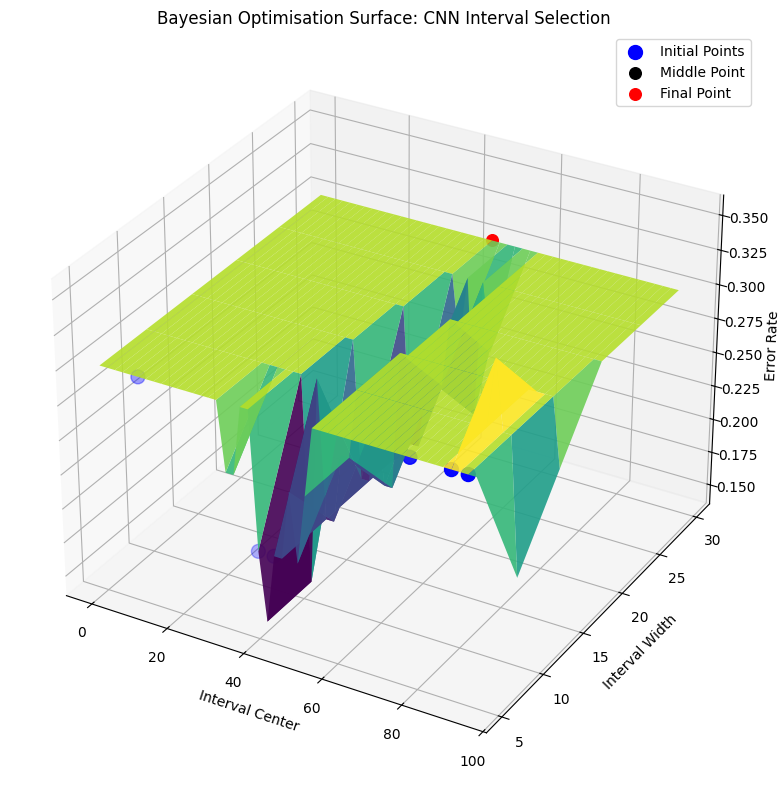

In [188]:
# CNN BO 3D print

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# --- CNN model ---
class Simple1DCNN(nn.Module):
    def __init__(self, input_length, num_classes=2):
        super(Simple1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

# --- Interval and training function ---
def get_sampled_interval(patient_data, center, interval_width):
    start = max(0, center - interval_width // 2)
    end = min(patient_data.shape[1], center + interval_width // 2)
    return start, end

def train_nn(patient_data, labels, center, interval_width):
    start, end = get_sampled_interval(patient_data, center, interval_width)
    x = patient_data[:, start:end].astype(np.float32)
    y = (labels == 1).astype(np.int64)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
    model = Simple1DCNN(input_length=x.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
    test_tensor = torch.tensor(x_test)

    model.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(test_tensor).argmax(dim=1).cpu().numpy()
    error_rate = 1 - accuracy_score(y_test, preds)
    return error_rate

# --- Define grid and compute surface ---
interval_widths = np.arange(5, 31, 5)
centers = np.arange(0, patient_data.shape[1], 2)
error_surface = np.zeros((len(interval_widths), len(centers)))

for i, w in enumerate(interval_widths):
    for j, c in enumerate(centers):
        error_surface[i, j] = train_nn(patient_data, labels, c, w)

# --- Simulated key points (replace with actual tracked ones if available) ---
initial_centers = np.sort(np.random.choice(centers, 10, replace=False))
middle_center = centers[len(centers)//2]
final_center = centers[np.argmin(np.mean(error_surface, axis=0))]

# --- 3D Plot ---
X, Y = np.meshgrid(centers, interval_widths)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, error_surface, cmap='viridis', alpha=0.9)

ax.scatter(initial_centers, [interval_widths[0]]*len(initial_centers), 
           [train_nn(patient_data, labels, c, interval_widths[0]) for c in initial_centers], 
           color='blue', label='Initial Points', s=100)

ax.scatter(middle_center, interval_widths[len(interval_widths)//2], 
           train_nn(patient_data, labels, middle_center, interval_widths[len(interval_widths)//2]), 
           color='black', label='Middle Point', s=70)

ax.scatter(final_center, interval_widths[-1], 
           train_nn(patient_data, labels, final_center, interval_widths[-1]), 
           color='red', label='Final Point', s=70)

ax.set_xlabel('Interval Center')
ax.set_ylabel('Interval Width')
ax.set_zlabel('Error Rate')
ax.set_title('Bayesian Optimisation Surface: CNN Interval Selection')
ax.legend()
plt.tight_layout()
plt.show()


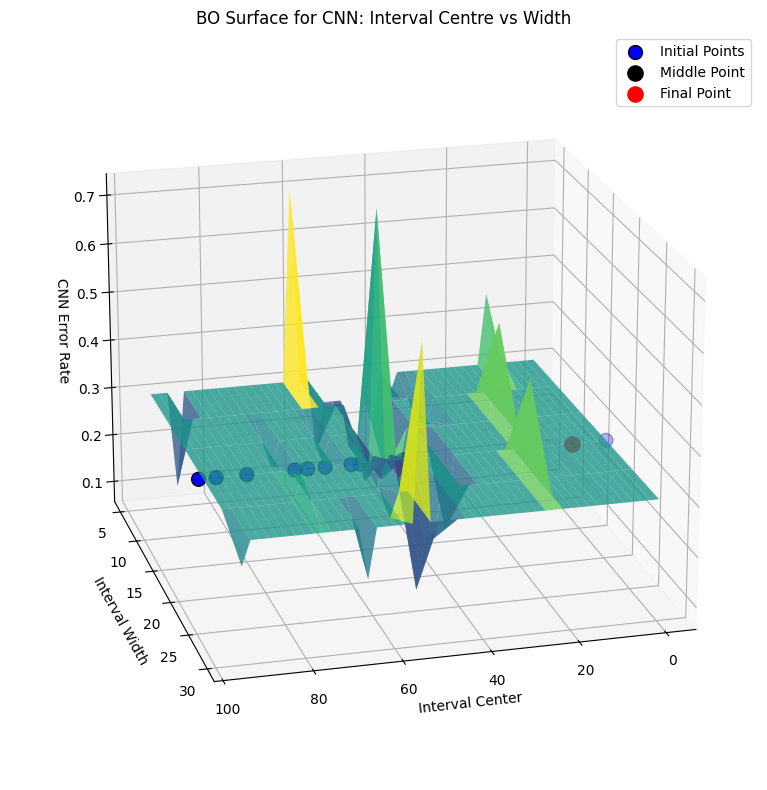

In [197]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate surface from actual CNN error evaluations across a grid of (center, width)
interval_widths = np.arange(5, 31, 5)
centers = np.arange(0, patient_data.shape[1], 2)
X, Y = np.meshgrid(centers, interval_widths)
Z = np.zeros_like(X, dtype=float)

# Fill Z surface using actual CNN training function
for i, w in enumerate(interval_widths):
    for j, c in enumerate(centers):
        start = max(0, c - w // 2)
        end = min(patient_data.shape[1], c + w // 2)
        if end - start < 2:  # Ensure minimum size for training
            Z[i, j] = np.nan
            continue
        x = patient_data[:, start:end].astype(np.float32)
        y = (labels == 1).astype(np.int64)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

        model = Simple1DCNN(input_length=x.shape[1])
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        train_loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)), batch_size=32, shuffle=True)
        test_tensor = torch.tensor(x_test)

        model.train()
        for epoch in range(5):  # Use fewer epochs for faster plotting
            for batch_x, batch_y in train_loader:
                optimizer.zero_grad()
                output = model(batch_x)
                loss = criterion(output, batch_y)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(test_tensor).argmax(dim=1).cpu().numpy()
        Z[i, j] = 1 - accuracy_score(y_test, preds)

# Identify plotting points
initial_centers = sampled_centers
middle_center = centers[len(centers) // 2]
final_center = best_center

initial_width = interval_width
middle_width = interval_width
final_width = interval_width

# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

# Initial points
ax.scatter(sampled_centers, [interval_width]*len(sampled_centers),
           [train_nn(patient_data, labels, c, interval_width) for c in sampled_centers],
           color='blue', s=100, label='Initial Points', edgecolors='black')

# Middle point
middle_center = centers[len(centers)//2]
ax.scatter(middle_center, interval_width,
           train_nn(patient_data, labels, middle_center, interval_width),
           color='black', s=120, label='Middle Point')

# Final point
ax.scatter(best_center, interval_width,
           train_nn(patient_data, labels, best_center, interval_width),
           color='red', s=120, label='Final Point')
ax.view_init(elev=20, azim=75)
ax.set_xlabel('Interval Center')
ax.set_ylabel('Interval Width')
ax.set_zlabel('CNN Error Rate')
ax.set_title('BO Surface for CNN: Interval Centre vs Width')
ax.legend()
plt.tight_layout()
plt.show()



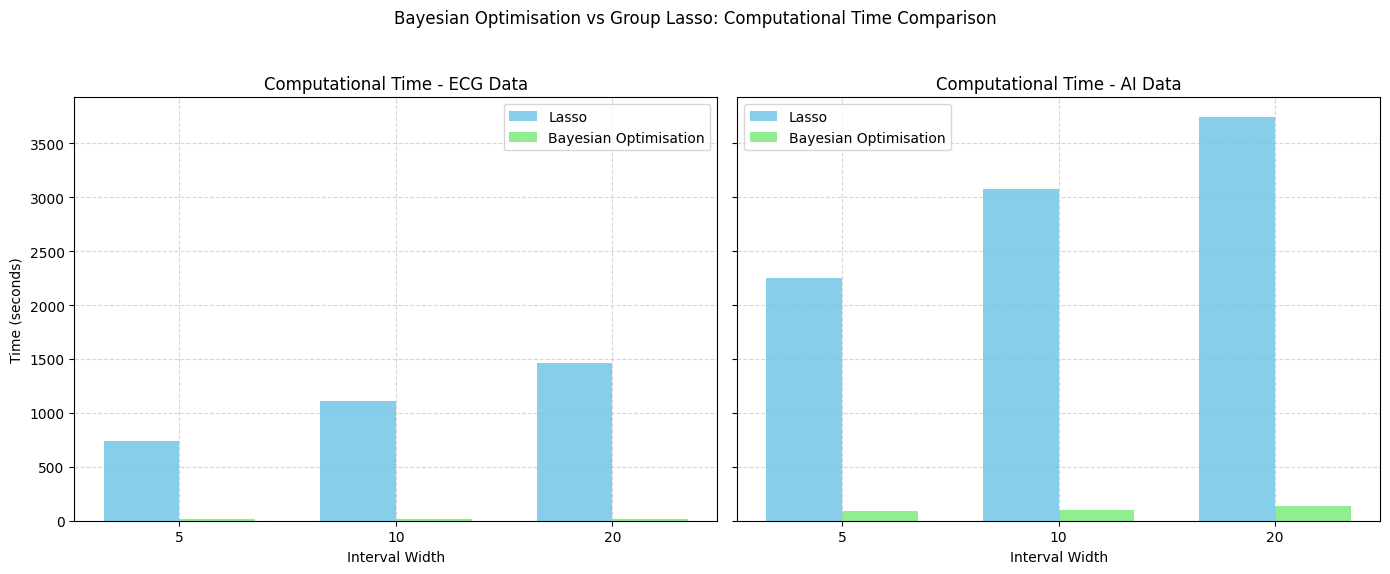

In [189]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the image

intervals = [5, 10, 20]

# Times in seconds
ecg_lasso = [12*60 + 20, 18*60 + 32, 24*60 + 27]
ecg_bo = [17, 19, 20]

ai_lasso = [37*60 + 30, 51*60 + 17, 62*60 + 19]
ai_bo = [92, 97, 140]

bar_width = 0.35
x = np.arange(len(intervals))

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ECG data plot
axs[0].bar(x - bar_width/2, ecg_lasso, bar_width, label='Lasso', color='skyblue')
axs[0].bar(x + bar_width/2, ecg_bo, bar_width, label='Bayesian Optimisation', color='lightgreen')
axs[0].set_title('Computational Time - ECG Data')
axs[0].set_xlabel('Interval Width')
axs[0].set_ylabel('Time (seconds)')
axs[0].set_xticks(x)
axs[0].set_xticklabels(intervals)
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

# AI data plot
axs[1].bar(x - bar_width/2, ai_lasso, bar_width, label='Lasso', color='skyblue')
axs[1].bar(x + bar_width/2, ai_bo, bar_width, label='Bayesian Optimisation', color='lightgreen')
axs[1].set_title('Computational Time - AI Data')
axs[1].set_xlabel('Interval Width')
axs[1].set_xticks(x)
axs[1].set_xticklabels(intervals)
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Bayesian Optimisation vs Group Lasso: Computational Time Comparison')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


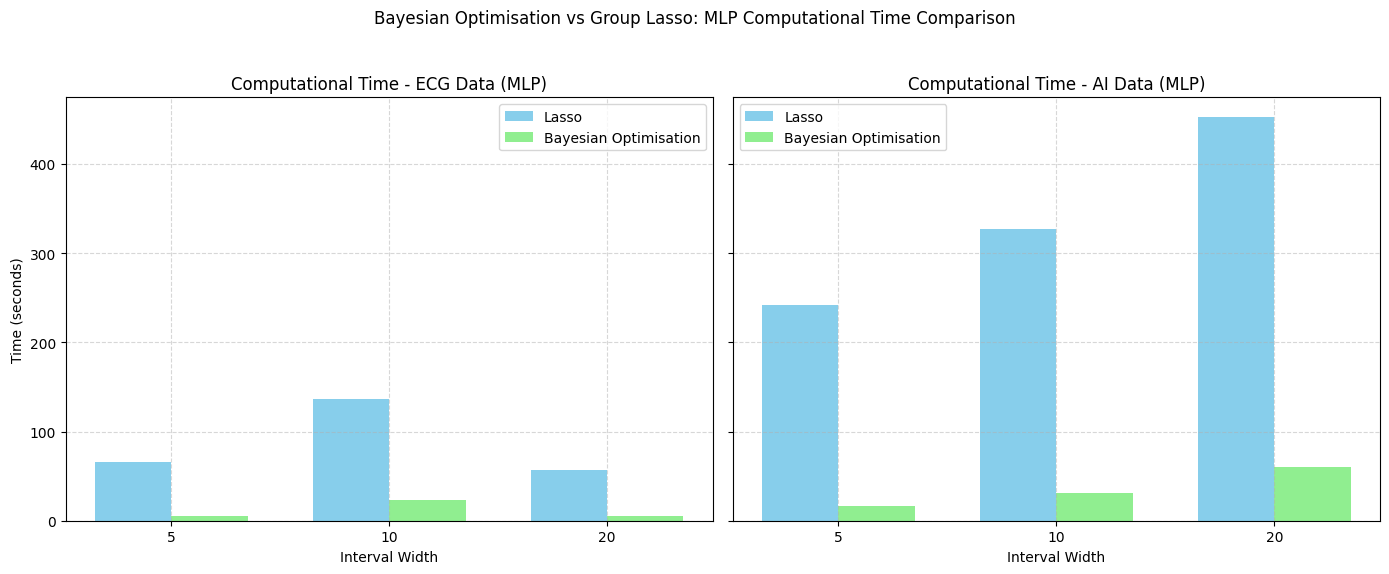

In [190]:
import matplotlib.pyplot as plt
import numpy as np

# Interval widths
intervals = [5, 10, 20]

# Convert Lasso and BO times to seconds
ecg_lasso_mlp = [66, 137, 56.8]
ecg_bo_mlp = [5, 23, 5]

ai_lasso_mlp = [4*60 + 2, 5*60 + 27, 7*60 + 32]
ai_bo_mlp = [16, 31, 60]

bar_width = 0.35
x = np.arange(len(intervals))

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ECG data plot
axs[0].bar(x - bar_width/2, ecg_lasso_mlp, bar_width, label='Lasso', color='skyblue')
axs[0].bar(x + bar_width/2, ecg_bo_mlp, bar_width, label='Bayesian Optimisation', color='lightgreen')
axs[0].set_title('Computational Time - ECG Data (MLP)')
axs[0].set_xlabel('Interval Width')
axs[0].set_ylabel('Time (seconds)')
axs[0].set_xticks(x)
axs[0].set_xticklabels(intervals)
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

# AI data plot
axs[1].bar(x - bar_width/2, ai_lasso_mlp, bar_width, label='Lasso', color='skyblue')
axs[1].bar(x + bar_width/2, ai_bo_mlp, bar_width, label='Bayesian Optimisation', color='lightgreen')
axs[1].set_title('Computational Time - AI Data (MLP)')
axs[1].set_xlabel('Interval Width')
axs[1].set_xticks(x)
axs[1].set_xticklabels(intervals)
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Bayesian Optimisation vs Group Lasso: MLP Computational Time Comparison')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
